In [ ]:
import os
os.chdir("Type the working path")

# Definition of EM and VARISEM

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import digamma, logsumexp
from sklearn.mixture import BayesianGaussianMixture
from sklearn.metrics import adjusted_rand_score
from scipy.special import digamma, logsumexp, gammaln


class VARISEM:
    def __init__(self, X, K, max_iter=200, tol=1e-6):
        self.X = X
        self.N, self.D = X.shape
        self.K = K
        self.max_iter = max_iter
        self.tol = tol

        self.alpha_prior = np.ones(K) * 10  
        self.a_prior = np.ones((K, D)) * 5  
        self.b_prior = np.ones((K, D)) * 10  

        bmm = BayesianGaussianMixture(
            n_components=K, covariance_type="full",
            weight_concentration_prior_type="dirichlet_process",
            random_state=42, max_iter=100, n_init=10
        )
        bmm.fit(X)
        self.q_nk = bmm.predict_proba(X)  

        #self.alpha_q = self.alpha_prior.copy()
        self.alpha_q = self.alpha_prior + np.sum(self.q_nk, axis=0)
        self.a_q = self.a_prior.copy() + np.dot(self.q_nk.T, self.X)
        self.b_q = self.b_prior.copy() + np.dot(self.q_nk.T, 1 - self.X)

    def update_q_nk(self):
        log_pi_k = digamma(self.alpha_q) - digamma(np.sum(self.alpha_q))
        log_mu_ki = digamma(self.a_q) - digamma(self.a_q + self.b_q)
        log_1_mu_ki = digamma(self.b_q) - digamma(self.a_q + self.b_q)

        log_q_nk = log_pi_k + np.sum(
            self.X[:, None, :] * log_mu_ki[None, :, :] + (1 - self.X[:, None, :]) * log_1_mu_ki[None, :, :],
            axis=2
        )

        log_q_nk -= logsumexp(log_q_nk, axis=1, keepdims=True)
        self.q_nk = np.exp(log_q_nk)

    def update_pi_k(self):
        self.alpha_q = self.alpha_prior + np.sum(self.q_nk, axis=0)
        self.pi_k_mean = self.alpha_q / np.sum(self.alpha_q)

    def update_mu_ki(self):
        self.a_q = self.a_prior + np.dot(self.q_nk.T, self.X)
        self.b_q = self.b_prior + np.dot(self.q_nk.T, 1 - self.X)
        self.mu_ki_mean = self.a_q / (self.a_q + self.b_q)
        
    def compute_elbo(self):
        log_mu_ki = digamma(self.a_q) - digamma(self.a_q + self.b_q)
        log_1_mu_ki = digamma(self.b_q) - digamma(self.a_q + self.b_q)

        log_likelihood = np.sum(self.q_nk[:, :, None] * (
            self.X[:, None, :] * log_mu_ki[None, :, :] +
            (1 - self.X[:, None, :]) * log_1_mu_ki[None, :, :]
        ))

        log_pi_k = digamma(self.alpha_q) - digamma(np.sum(self.alpha_q))

        log_prior_z = np.sum(self.q_nk * log_pi_k)
        log_prior_pi = np.sum((self.alpha_prior - 1) * log_pi_k)
        log_prior_mu = np.sum((self.a_prior - 1) * log_mu_ki + (self.b_prior - 1) * log_1_mu_ki)

        entropy_q_z = -np.sum(self.q_nk * np.log(self.q_nk + 1e-10))

        alpha_0 = np.sum(self.alpha_q)
        dirichlet_entropy = (
            gammaln(alpha_0) - np.sum(gammaln(self.alpha_q))
            + (alpha_0 - self.K) * digamma(alpha_0)
            - np.sum((self.alpha_q - 1) * digamma(self.alpha_q))
        )

        beta_entropy = np.sum(
            gammaln(self.a_q + self.b_q) - gammaln(self.a_q) - gammaln(self.b_q)
            - (self.a_q - 1) * digamma(self.a_q)
            - (self.b_q - 1) * digamma(self.b_q)
            + (self.a_q + self.b_q - 2) * digamma(self.a_q + self.b_q)
        )

        elbo = (
            log_likelihood
            + log_prior_z
            + log_prior_pi
            + log_prior_mu
            + entropy_q_z
            + dirichlet_entropy
            + beta_entropy
        )

        return elbo  # <-- Proper indentation

    def fit(self):
        elbo_old = -np.inf
        self.elbo_values = []

        for iteration in range(self.max_iter):
            self.update_q_nk()
            self.update_pi_k()
            self.update_mu_ki()

            elbo = self.compute_elbo()
            self.elbo_values.append(elbo)

            if np.abs(elbo - elbo_old) < self.tol:
                print(f"Converged at iteration {iteration}.")
                break
            elbo_old = elbo

            if iteration % 10 == 0:
                print(f"Iteration {iteration}, ELBO: {elbo:.4f}")

        print("Optimization complete.")

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import logsumexp
from sklearn.metrics import adjusted_rand_score

class DREEM:
    def __init__(self, X, K, max_iter=100, tol=1e-6):
        self.X = X
        self.N, self.D = X.shape
        self.K = K
        self.max_iter = max_iter
        self.tol = tol

        # Initialize parameters
        self.pi = np.ones(K) / K  # Uniform cluster proportions
        self.mu = np.random.rand(K, self.D)  # Random mutation probabilities
        self.responsibilities = np.zeros((self.N, self.K))  # Cluster responsibilities
        self.log_likelihoods = []

    def e_step(self):
        log_likelihood = np.zeros((self.N, self.K))
        for k in range(self.K):
            log_likelihood[:, k] = np.sum(
                self.X * np.log(np.clip(self.mu[k], 1e-10, 1 - 1e-10)) +
                (1 - self.X) * np.log(np.clip(1 - self.mu[k], 1e-10, 1 - 1e-10)),
                axis=1
            ) + np.log(self.pi[k] + 1e-10)

        log_responsibilities = log_likelihood - logsumexp(log_likelihood, axis=1, keepdims=True)
        self.responsibilities = np.exp(log_responsibilities)

    def m_step(self):
        N_k = np.sum(self.responsibilities, axis=0)
        self.pi = N_k / self.N
        for k in range(self.K):
            self.mu[k] = np.sum(self.responsibilities[:, k, None] * self.X, axis=0) / (N_k[k] + 1e-10)

    def compute_log_likelihood(self):
        log_likelihood = np.zeros((self.N, self.K))
        for k in range(self.K):
            log_likelihood[:, k] = np.sum(
                self.X * np.log(np.clip(self.mu[k], 1e-10, 1 - 1e-10)) +
                (1 - self.X) * np.log(np.clip(1 - self.mu[k], 1e-10, 1 - 1e-10)),
                axis=1
            ) + np.log(self.pi[k] + 1e-10)
        return np.sum(logsumexp(log_likelihood, axis=1))

    def fit(self):
        log_likelihood_old = -np.inf
        for iteration in range(self.max_iter):
            self.e_step()
            self.m_step()

            log_likelihood = self.compute_log_likelihood()
            self.log_likelihoods.append(log_likelihood)

            if np.abs(log_likelihood - log_likelihood_old) < self.tol:
                print(f"Converged at iteration {iteration}.")
                break
            log_likelihood_old = log_likelihood
        print("Optimization complete.")

    def predict(self):
        return np.argmax(self.responsibilities, axis=1)

In [4]:
def kl_bernoulli(p, q, epsilon=1e-10):
    p = np.clip(p, epsilon, 1 - epsilon)
    q = np.clip(q, epsilon, 1 - epsilon)
    kl = p * np.log(p / q) + (1 - p) * np.log((1 - p) / (1 - q))
    return np.sum(kl)

# K=3

In [5]:
import os
output_folder = "k=3"
os.makedirs(output_folder, exist_ok=True)

D_values = np.arange(100, 2000, 100)
#D_values = [50, 100,150, 200, 250,300, 400, 500, 600, 700, 800, 900, 1000]
N_values = [100, 200, 300, 500, 600, 800]

results = []

for D in D_values:
    for N in N_values:
        np.random.seed(314)
        K = 3
        alpha = np.ones(K) * 2

        pi_true = np.random.dirichlet(alpha)
        a, b = 2, 5
        mu_true = np.random.beta(a, b, (K, D))

        Z_true = np.random.choice(K, size=N, p=pi_true)
        X_D = np.zeros((N, D), dtype=int)

        for n in range(N):
            cluster = Z_true[n]
            X_D[n, :] = np.random.binomial(1, mu_true[cluster, :])

        vi_model_bmm_mean = VARISEM(X_D, K, max_iter=300, tol=1e-6)
        vi_model_bmm_mean.fit()

        Z_pred = np.argmax(vi_model_bmm_mean.q_nk, axis=1)
        ari_score = adjusted_rand_score(Z_true, Z_pred)

        pi_estimated = vi_model_bmm_mean.pi_k_mean
        pi_mae = np.mean(np.abs(pi_true - pi_estimated))

        # Compute KL divergence for mu
        kl_divergences = []
        for k in range(K):
            kl_k = kl_bernoulli(mu_true[k, :], vi_model_bmm_mean.mu_ki_mean[k, :])
            kl_divergences.append(kl_k)
        kl_divergence_mean = np.mean(kl_divergences)

        results.append([D, N, ari_score, pi_mae, kl_divergence_mean])

# Create DataFrame
df_results = pd.DataFrame(results, columns=["D", "N", "ARI", "pi_MAE", "mu_KL"])
filename_csv = os.path.join(output_folder, "VARISEM_ARI_pi_mu_k=3.csv")
df_results.to_csv(filename_csv, index=False)

Iteration 0, ELBO: 8634.9970
Iteration 10, ELBO: 8565.7138
Converged at iteration 15.
Optimization complete.
Iteration 0, ELBO: 14144.5948
Iteration 10, ELBO: 14050.7819
Iteration 20, ELBO: 14050.8122
Iteration 30, ELBO: 14050.8168
Iteration 40, ELBO: 14050.8180
Iteration 50, ELBO: 14050.8183
Iteration 60, ELBO: 14050.8184
Iteration 70, ELBO: 14050.8184
Converged at iteration 77.
Optimization complete.
Iteration 0, ELBO: 19821.0980
Iteration 10, ELBO: 19577.5985
Iteration 20, ELBO: 19576.7212
Iteration 30, ELBO: 19576.7155
Converged at iteration 37.
Optimization complete.
Iteration 0, ELBO: 31008.5739
Iteration 10, ELBO: 30613.8497
Iteration 20, ELBO: 30612.8287
Converged at iteration 27.
Optimization complete.
Iteration 0, ELBO: 35998.0638
Iteration 10, ELBO: 35995.4105
Converged at iteration 18.
Optimization complete.
Iteration 0, ELBO: 46887.3077
Iteration 10, ELBO: 46886.3804
Converged at iteration 13.
Optimization complete.
Iteration 0, ELBO: 16817.6959
Converged at iteration 2.
O

In [6]:
results = []

for D in D_values:
    for N in N_values:
        np.random.seed(314)
        K = 3
        alpha = np.ones(K) * 2

        # Generate true parameters
        pi_true = np.random.dirichlet(alpha)
        a, b = 2, 5
        mu_true = np.random.beta(a, b, (K, D))

        Z_true = np.random.choice(K, size=N, p=pi_true)
        X_D = np.zeros((N, D), dtype=int)

        for n in range(N):
            cluster = Z_true[n]
            X_D[n, :] = np.random.binomial(1, mu_true[cluster, :])

        # Run DREEM
        dreem_model = DREEM(X_D, K, max_iter=300, tol=1e-6)
        dreem_model.fit()

        Z_pred_dreem = dreem_model.predict()
        ari_dreem = adjusted_rand_score(Z_true, Z_pred_dreem)

        # Calculate pi MAE
        pi_estimated = dreem_model.pi
        pi_mae = np.mean(np.abs(pi_true - pi_estimated))

        # Calculate mu KL divergence
        kl_divergences = []
        for k in range(K):
            kl_k = kl_bernoulli(mu_true[k, :], dreem_model.mu[k, :])
            kl_divergences.append(kl_k)
        mu_kl = np.mean(kl_divergences)

        results.append([D, N, ari_dreem, pi_mae, mu_kl])


df_results = pd.DataFrame(results, columns=["D", "N", "ARI_DREEM", "pi_MAE_DREEM", "mu_KL_DREEM"])
filename_csv = os.path.join(output_folder, "DREEM_ARI_pi_mu_k=3.csv")
df_results.to_csv(filename_csv, index=False)

Converged at iteration 36.
Optimization complete.
Converged at iteration 13.
Optimization complete.
Converged at iteration 62.
Optimization complete.
Converged at iteration 15.
Optimization complete.
Converged at iteration 14.
Optimization complete.
Converged at iteration 14.
Optimization complete.
Converged at iteration 10.
Optimization complete.
Converged at iteration 9.
Optimization complete.
Converged at iteration 17.
Optimization complete.
Converged at iteration 8.
Optimization complete.
Converged at iteration 6.
Optimization complete.
Converged at iteration 96.
Optimization complete.
Converged at iteration 17.
Optimization complete.
Converged at iteration 22.
Optimization complete.
Converged at iteration 7.
Optimization complete.
Converged at iteration 4.
Optimization complete.
Converged at iteration 6.
Optimization complete.
Converged at iteration 6.
Optimization complete.
Converged at iteration 12.
Optimization complete.
Converged at iteration 6.
Optimization complete.
Converge

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

filename_dreem_csv = os.path.join(output_folder, "DREEM_ARI_pi_mu_k=5.csv")
filename_varisem_csv = os.path.join(output_folder, "VARISEM_ARI_pi_mu_k=5.csv")
df_dreem = pd.read_csv(filename_dreem_csv)
df_varisem = pd.read_csv(filename_varisem_csv)

# Merge on D and N
df_combined = pd.merge(
    df_dreem,
    df_varisem,
    on=["D", "N"],
    suffixes=("_DREEM", "_VARISEM")
)

# Summary statistics
df_summary = df_combined.groupby("D").agg({
    "ARI_DREEM": ["mean", "min", "max"],
    "ARI": ["mean", "min", "max"],             # VARISEM ARI
    "pi_MAE_DREEM": ["mean", "min", "max"],
    "pi_MAE": ["mean", "min", "max"],          # VARISEM pi_MAE
    "mu_KL_DREEM": ["mean", "min", "max"],
    "mu_KL": ["mean", "min", "max"]            # VARISEM mu_KL
}).reset_index()

# Flatten MultiIndex columns
df_summary.columns = [
    "D",
    "ARI_DREEM_mean", "ARI_DREEM_min", "ARI_DREEM_max",
    "ARI_VARISEM_mean", "ARI_VARISEM_min", "ARI_VARISEM_max",
    "pi_MAE_DREEM_mean", "pi_MAE_DREEM_min", "pi_MAE_DREEM_max",
    "pi_MAE_VARISEM_mean", "pi_MAE_VARISEM_min", "pi_MAE_VARISEM_max",
    "mu_KL_DREEM_mean", "mu_KL_DREEM_min", "mu_KL_DREEM_max",
    "mu_KL_VARISEM_mean", "mu_KL_VARISEM_min", "mu_KL_VARISEM_max"
]

# -------------------------
# Compute Error Bars
# -------------------------

# ARI Error Bars
df_summary["ARI_DREEM_min_err"] = df_summary["ARI_DREEM_mean"] - df_summary["ARI_DREEM_min"]
df_summary["ARI_DREEM_max_err"] = df_summary["ARI_DREEM_max"] - df_summary["ARI_DREEM_mean"]
df_summary["ARI_VARISEM_min_err"] = df_summary["ARI_VARISEM_mean"] - df_summary["ARI_VARISEM_min"]
df_summary["ARI_VARISEM_max_err"] = df_summary["ARI_VARISEM_max"] - df_summary["ARI_VARISEM_mean"]

# pi_MAE Error Bars
df_summary["pi_MAE_DREEM_min_err"] = df_summary["pi_MAE_DREEM_mean"] - df_summary["pi_MAE_DREEM_min"]
df_summary["pi_MAE_DREEM_max_err"] = df_summary["pi_MAE_DREEM_max"] - df_summary["pi_MAE_DREEM_mean"]
df_summary["pi_MAE_VARISEM_min_err"] = df_summary["pi_MAE_VARISEM_mean"] - df_summary["pi_MAE_VARISEM_min"]
df_summary["pi_MAE_VARISEM_max_err"] = df_summary["pi_MAE_VARISEM_max"] - df_summary["pi_MAE_VARISEM_mean"]

# mu_KL Error Bars
df_summary["mu_KL_DREEM_min_err"] = df_summary["mu_KL_DREEM_mean"] - df_summary["mu_KL_DREEM_min"]
df_summary["mu_KL_DREEM_max_err"] = df_summary["mu_KL_DREEM_max"] - df_summary["mu_KL_DREEM_mean"]
df_summary["mu_KL_VARISEM_min_err"] = df_summary["mu_KL_VARISEM_mean"] - df_summary["mu_KL_VARISEM_min"]
df_summary["mu_KL_VARISEM_max_err"] = df_summary["mu_KL_VARISEM_max"] - df_summary["mu_KL_VARISEM_mean"]

# -------------------------
# Normalize mu_KL values per D group
# -------------------------

# Compute min/max across both methods for mu_KL at the summary level
df_summary["KL_min"] = df_summary[["mu_KL_DREEM_mean", "mu_KL_VARISEM_mean"]].min(axis=1)
df_summary["KL_max"] = df_summary[["mu_KL_DREEM_mean", "mu_KL_VARISEM_mean"]].max(axis=1)

# Normalize mean mu_KL values
df_summary["mu_KL_DREEM_norm"] = (df_summary["mu_KL_DREEM_mean"] - df_summary["KL_min"]) / (df_summary["KL_max"] - df_summary["KL_min"])
df_summary["mu_KL_VARISEM_norm"] = (df_summary["mu_KL_VARISEM_mean"] - df_summary["KL_min"]) / (df_summary["KL_max"] - df_summary["KL_min"])

# -------------------------
# Normalize mu_KL at row level for df_combined
# -------------------------

# Compute min/max per D across both methods
kl_min_max = df_combined.groupby("D")[["mu_KL_DREEM", "mu_KL"]].agg(["min", "max"]).reset_index()

# Flatten columns
kl_min_max.columns = [
    "D",
    "mu_KL_DREEM_min", "mu_KL_DREEM_max",
    "mu_KL_VARISEM_min", "mu_KL_VARISEM_max"
]

# Compute KL_min and KL_max for normalization
kl_min_max["KL_min"] = kl_min_max[["mu_KL_DREEM_min", "mu_KL_VARISEM_min"]].min(axis=1)
kl_min_max["KL_max"] = kl_min_max[["mu_KL_DREEM_max", "mu_KL_VARISEM_max"]].max(axis=1)

# Merge KL_min and KL_max back into df_combined for normalization
df_combined = df_combined.merge(kl_min_max[["D", "KL_min", "KL_max"]], on="D", how="left")

# Normalize row-level mu_KL values
df_combined["mu_KL_DREEM_norm"] = (df_combined["mu_KL_DREEM"] - df_combined["KL_min"]) / (df_combined["KL_max"] - df_combined["KL_min"])
df_combined["mu_KL_VARISEM_norm"] = (df_combined["mu_KL"] - df_combined["KL_min"]) / (df_combined["KL_max"] - df_combined["KL_min"])

# Aggregate normalized scores at D level
df_summary_norm = df_combined.groupby("D").agg({
    "mu_KL_DREEM_norm": "mean",
    "mu_KL_VARISEM_norm": "mean"
}).reset_index()

# Rename columns for clarity
df_summary_norm.columns = ["D", "DREEM_mean", "VARISEM_mean"]

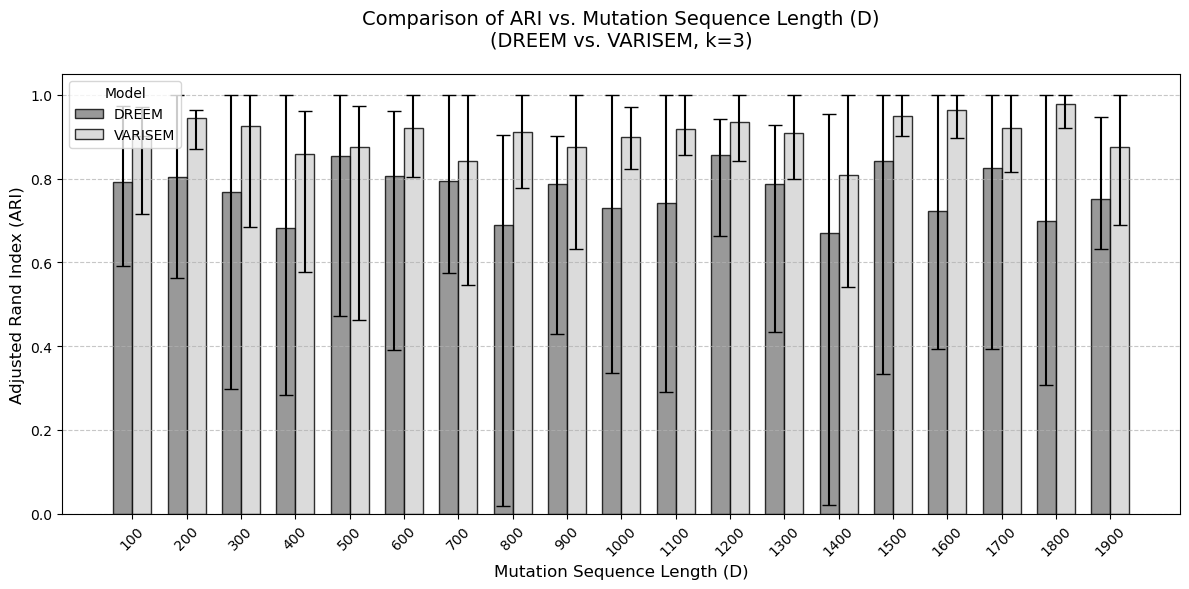

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Setup
bar_width = 0.35
x_positions = np.arange(len(df_summary["D"]))

plt.figure(figsize=(12, 6))

# Plot DREEM ARI
plt.bar(
    x_positions - bar_width / 2,
    df_summary["ARI_DREEM_mean"],
    yerr=[
        df_summary["ARI_DREEM_min_err"],
        df_summary["ARI_DREEM_max_err"]
    ],
    capsize=5,
    color="gray",
    edgecolor="black",
    width=bar_width,
    label="DREEM",
    alpha=0.8
)

# Plot VARISEM ARI
plt.bar(
    x_positions + bar_width / 2,
    df_summary["ARI_VARISEM_mean"],
    yerr=[
        df_summary["ARI_VARISEM_min_err"],
        df_summary["ARI_VARISEM_max_err"]
    ],
    capsize=5,
    color="lightgray",
    edgecolor="black",
    width=bar_width,
    label="VARISEM",
    alpha=0.8
)


# Labels and title
plt.xlabel("Mutation Sequence Length (D)", fontsize=12)
plt.ylabel("Adjusted Rand Index (ARI)", fontsize=12)
plt.title("Comparison of ARI vs. Mutation Sequence Length (D)\n(DREEM vs. VARISEM, k=3)", fontsize=14, pad=20)
plt.xticks(x_positions, df_summary["D"], rotation=45, fontsize=10)

plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.legend(title="Model", loc="upper left")

# Save and show the plot
plt.tight_layout()                  
filename = os.path.join(output_folder, "ARI_VARISEM_vs_DREEM_k=3.pdf")
plt.savefig(filename, format='pdf')
plt.show()

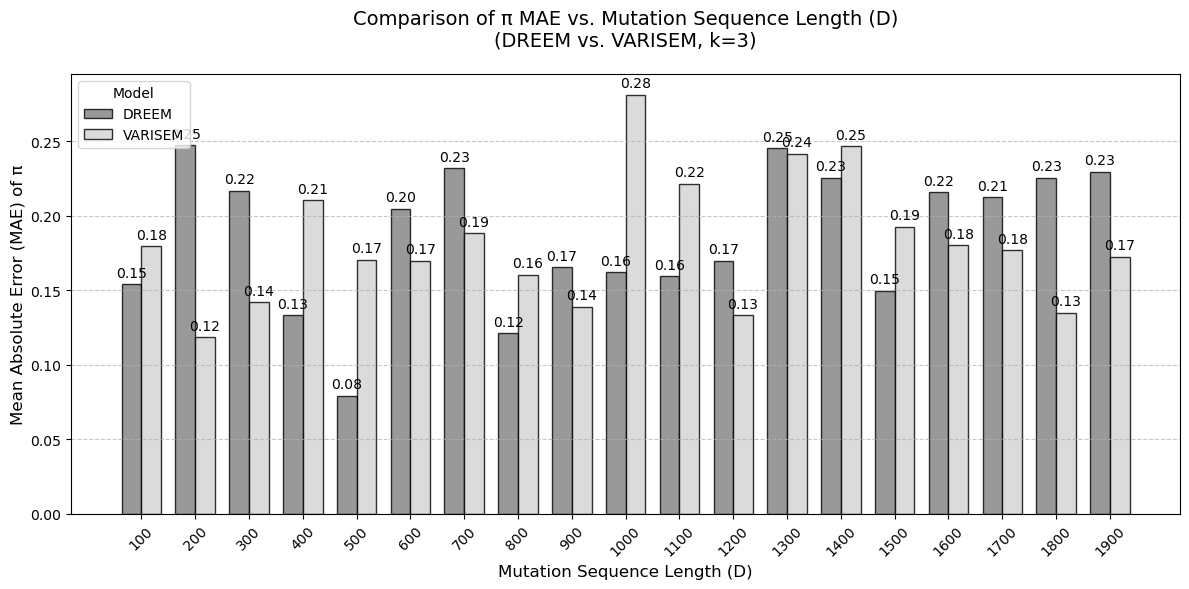

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting parameters
bar_width = 22
spacing = 60

# Generate x-axis positions for each D value
x_labels = df_summary["D"]
x_positions = np.arange(len(x_labels)) * spacing

# Create the figure
plt.figure(figsize=(12, 6))

# Plot DREEM pi_MAE bars
bars_dreem = plt.bar(
    x_positions - bar_width / 2,
    df_summary["pi_MAE_DREEM_mean"],
    color="gray",
    edgecolor="black",
    width=bar_width,
    label="DREEM",
    alpha=0.8
)

# Plot VARISEM pi_MAE bars
bars_varisem = plt.bar(
    x_positions + bar_width / 2,
    df_summary["pi_MAE_VARISEM_mean"],
    color="lightgray",
    edgecolor="black",
    width=bar_width,
    label="VARISEM",
    alpha=0.8
)

# Add value labels on top of each bar
for bar, value in zip(bars_dreem, df_summary["pi_MAE_DREEM_mean"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,     # A small offset above the bar
        f"{value:.2f}",              # Format to 3 decimal places (adjust as needed)
        ha="center",
        va="bottom",
        fontsize=10
    )

for bar, value in zip(bars_varisem, df_summary["pi_MAE_VARISEM_mean"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Customize labels and title
plt.xlabel("Mutation Sequence Length (D)", fontsize=12)
plt.ylabel("Mean Absolute Error (MAE) of π", fontsize=12)
plt.title("Comparison of π MAE vs. Mutation Sequence Length (D)\n(DREEM vs. VARISEM, k=3)", fontsize=14, pad=20)

# Customize ticks
plt.xticks(x_positions, x_labels, rotation=45, fontsize=10)
plt.yticks(fontsize=10)

# Add grid and legend
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.legend(title="Model", loc="upper left")
# Save and show the plot
plt.tight_layout()
filename = os.path.join(output_folder, "pi_MAE_VARISEM_vs_DREEM_k=3.pdf")
plt.savefig(filename, format='pdf')      
plt.show()


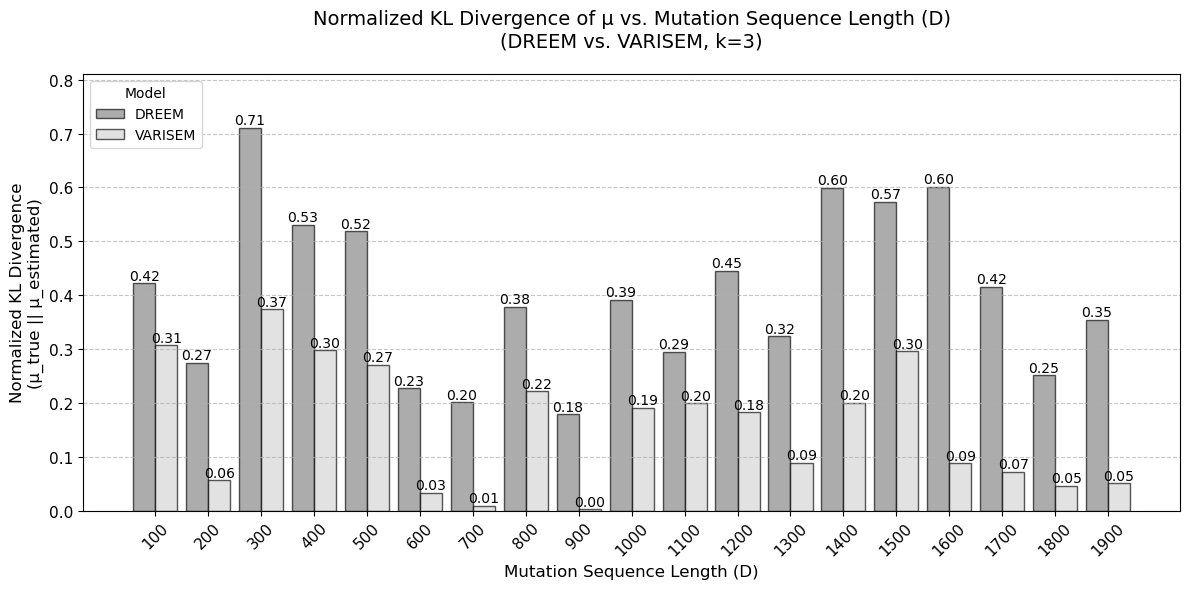

In [10]:
# Plotting parameters
bar_width = 25
spacing = 60  # space between groups

# Generate x-axis positions for each D value
x_labels = df_summary_norm["D"]  # <--- use df_summary_norm here
x_positions = np.arange(len(x_labels)) * spacing

plt.figure(figsize=(12, 6))

# Plot DREEM normalized KL divergence bars
bars_dreem = plt.bar(
    x_positions - bar_width / 2,
    df_summary_norm["DREEM_mean"],  # <--- use df_summary_norm
    color="gray",
    edgecolor="black",
    width=bar_width,
    label="DREEM",
    alpha=0.65
)

# Plot VARISEM normalized KL divergence bars
bars_varisem = plt.bar(
    x_positions + bar_width / 2,
    df_summary_norm["VARISEM_mean"],  # <--- use df_summary_norm
    color="lightgray",
    edgecolor="black",
    width=bar_width,
    label="VARISEM",
    alpha=0.65
)

# Add value labels for both bars
for bar, value in zip(bars_dreem, df_summary_norm["DREEM_mean"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

for bar, value in zip(bars_varisem, df_summary_norm["VARISEM_mean"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Customize labels and title
plt.xlabel("Mutation Sequence Length (D)", fontsize=12)
plt.ylabel("Normalized KL Divergence\n(μ_true || μ_estimated)", fontsize=12)
plt.title("Normalized KL Divergence of μ vs. Mutation Sequence Length (D)\n(DREEM vs. VARISEM, k=3)", fontsize=14, pad=20)

plt.xticks(x_positions, x_labels, rotation=45, fontsize=11)
plt.yticks(fontsize=11)

# Y-axis limit adjustment
y_max = max(df_summary_norm["DREEM_mean"].max(), df_summary_norm["VARISEM_mean"].max()) + 0.1
plt.ylim(0, min(1, y_max))  # Cap the upper limit at 1 if necessary

plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.legend(title="Model", loc="upper left")
plt.tight_layout()

filename = os.path.join(output_folder, "mu_KL_normalized_VARISEM_vs_DREEM_k=3.pdf")
plt.savefig(filename, format='pdf')    
plt.show()


# K=4

In [11]:
output_folder = "k=4"
os.makedirs(output_folder, exist_ok=True)
D_values = np.arange(100, 2000, 100)
N_values = [100, 200, 300, 500, 600, 800]

results = []

for D in D_values:
    for N in N_values:
        np.random.seed(314)
        K = 4
        alpha = np.ones(K) * 2

        pi_true = np.random.dirichlet(alpha)
        a, b = 2, 5
        mu_true = np.random.beta(a, b, (K, D))

        Z_true = np.random.choice(K, size=N, p=pi_true)
        X_D = np.zeros((N, D), dtype=int)

        for n in range(N):
            cluster = Z_true[n]
            X_D[n, :] = np.random.binomial(1, mu_true[cluster, :])

        vi_model_bmm_mean = VARISEM(X_D, K, max_iter=300, tol=1e-6)
        vi_model_bmm_mean.fit()

        Z_pred = np.argmax(vi_model_bmm_mean.q_nk, axis=1)
        ari_score = adjusted_rand_score(Z_true, Z_pred)

        pi_estimated = vi_model_bmm_mean.pi_k_mean
        pi_mae = np.mean(np.abs(pi_true - pi_estimated))

        # Compute KL divergence for mu
        kl_divergences = []
        for k in range(K):
            kl_k = kl_bernoulli(mu_true[k, :], vi_model_bmm_mean.mu_ki_mean[k, :])
            kl_divergences.append(kl_k)
        kl_divergence_mean = np.mean(kl_divergences)

        results.append([D, N, ari_score, pi_mae, kl_divergence_mean])

# Create DataFrame
df_results = pd.DataFrame(results, columns=["D", "N", "ARI", "pi_MAE", "mu_KL"])
filename_csv = os.path.join(output_folder, "VARISEM_ARI_pi_mu_k=4.csv")
df_results.to_csv(filename_csv, index=False)


Iteration 0, ELBO: 9598.4513
Iteration 10, ELBO: 9544.7946
Converged at iteration 18.
Optimization complete.
Iteration 0, ELBO: 15280.3474
Iteration 10, ELBO: 15231.3703
Iteration 20, ELBO: 15188.3699
Iteration 30, ELBO: 15185.0195
Iteration 40, ELBO: 15185.0485
Iteration 50, ELBO: 15185.0526
Iteration 60, ELBO: 15185.0532
Iteration 70, ELBO: 15185.0533
Converged at iteration 78.
Optimization complete.
Iteration 0, ELBO: 20870.5682
Iteration 10, ELBO: 20830.5309
Iteration 20, ELBO: 20680.6112
Converged at iteration 30.
Optimization complete.
Iteration 0, ELBO: 31562.2301
Iteration 10, ELBO: 31559.7005
Converged at iteration 16.
Optimization complete.
Iteration 0, ELBO: 36927.4981
Iteration 10, ELBO: 36928.8014
Iteration 20, ELBO: 36928.8000
Converged at iteration 29.
Optimization complete.
Iteration 0, ELBO: 47881.2961
Iteration 10, ELBO: 47881.1628
Converged at iteration 13.
Optimization complete.
Iteration 0, ELBO: 18801.7315
Iteration 10, ELBO: 18747.5144
Converged at iteration 11.


In [12]:
results = []

for D in D_values:
    for N in N_values:
        np.random.seed(314)
        K = 4
        alpha = np.ones(K) * 2

        # Generate true parameters
        pi_true = np.random.dirichlet(alpha)
        a, b = 2, 5
        mu_true = np.random.beta(a, b, (K, D))

        Z_true = np.random.choice(K, size=N, p=pi_true)
        X_D = np.zeros((N, D), dtype=int)

        for n in range(N):
            cluster = Z_true[n]
            X_D[n, :] = np.random.binomial(1, mu_true[cluster, :])

        # Run DREEM
        dreem_model = DREEM(X_D, K, max_iter=300, tol=1e-6)
        dreem_model.fit()

        Z_pred_dreem = dreem_model.predict()
        ari_dreem = adjusted_rand_score(Z_true, Z_pred_dreem)

        # Calculate pi MAE
        pi_estimated = dreem_model.pi
        pi_mae = np.mean(np.abs(pi_true - pi_estimated))

        # Calculate mu KL divergence
        kl_divergences = []
        for k in range(K):
            kl_k = kl_bernoulli(mu_true[k, :], dreem_model.mu[k, :])
            kl_divergences.append(kl_k)
        mu_kl = np.mean(kl_divergences)

        results.append([D, N, ari_dreem, pi_mae, mu_kl])


df_results = pd.DataFrame(results, columns=["D", "N", "ARI_DREEM", "pi_MAE_DREEM", "mu_KL_DREEM"])
filename_csv = os.path.join(output_folder, "DREEM_ARI_pi_mu_k=4.csv")
df_results.to_csv(filename_csv, index=False)


Converged at iteration 22.
Optimization complete.
Converged at iteration 70.
Optimization complete.
Converged at iteration 44.
Optimization complete.
Converged at iteration 18.
Optimization complete.
Converged at iteration 19.
Optimization complete.
Converged at iteration 35.
Optimization complete.
Converged at iteration 19.
Optimization complete.
Converged at iteration 13.
Optimization complete.
Converged at iteration 7.
Optimization complete.
Converged at iteration 18.
Optimization complete.
Converged at iteration 108.
Optimization complete.
Converged at iteration 10.
Optimization complete.
Converged at iteration 39.
Optimization complete.
Converged at iteration 10.
Optimization complete.
Converged at iteration 7.
Optimization complete.
Converged at iteration 17.
Optimization complete.
Converged at iteration 6.
Optimization complete.
Converged at iteration 22.
Optimization complete.
Converged at iteration 7.
Optimization complete.
Converged at iteration 8.
Optimization complete.
Conv

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

filename_dreem_csv = os.path.join(output_folder, "DREEM_ARI_pi_mu_k=4.csv")
filename_varisem_csv = os.path.join(output_folder, "VARISEM_ARI_pi_mu_k=4.csv")

# Now read from those files
df_dreem = pd.read_csv(filename_dreem_csv)
df_varisem = pd.read_csv(filename_varisem_csv)

# Merge on D and N
df_combined = pd.merge(
    df_dreem,
    df_varisem,
    on=["D", "N"],
    suffixes=("_DREEM", "_VARISEM")
)

# Summary statistics
df_summary = df_combined.groupby("D").agg({
    "ARI_DREEM": ["mean", "min", "max"],
    "ARI": ["mean", "min", "max"],             # VARISEM ARI
    "pi_MAE_DREEM": ["mean", "min", "max"],
    "pi_MAE": ["mean", "min", "max"],          # VARISEM pi_MAE
    "mu_KL_DREEM": ["mean", "min", "max"],
    "mu_KL": ["mean", "min", "max"]            # VARISEM mu_KL
}).reset_index()

# Flatten MultiIndex columns
df_summary.columns = [
    "D",
    "ARI_DREEM_mean", "ARI_DREEM_min", "ARI_DREEM_max",
    "ARI_VARISEM_mean", "ARI_VARISEM_min", "ARI_VARISEM_max",
    "pi_MAE_DREEM_mean", "pi_MAE_DREEM_min", "pi_MAE_DREEM_max",
    "pi_MAE_VARISEM_mean", "pi_MAE_VARISEM_min", "pi_MAE_VARISEM_max",
    "mu_KL_DREEM_mean", "mu_KL_DREEM_min", "mu_KL_DREEM_max",
    "mu_KL_VARISEM_mean", "mu_KL_VARISEM_min", "mu_KL_VARISEM_max"
]

# -------------------------
# Compute Error Bars
# -------------------------

# ARI Error Bars
df_summary["ARI_DREEM_min_err"] = df_summary["ARI_DREEM_mean"] - df_summary["ARI_DREEM_min"]
df_summary["ARI_DREEM_max_err"] = df_summary["ARI_DREEM_max"] - df_summary["ARI_DREEM_mean"]
df_summary["ARI_VARISEM_min_err"] = df_summary["ARI_VARISEM_mean"] - df_summary["ARI_VARISEM_min"]
df_summary["ARI_VARISEM_max_err"] = df_summary["ARI_VARISEM_max"] - df_summary["ARI_VARISEM_mean"]

# pi_MAE Error Bars
df_summary["pi_MAE_DREEM_min_err"] = df_summary["pi_MAE_DREEM_mean"] - df_summary["pi_MAE_DREEM_min"]
df_summary["pi_MAE_DREEM_max_err"] = df_summary["pi_MAE_DREEM_max"] - df_summary["pi_MAE_DREEM_mean"]
df_summary["pi_MAE_VARISEM_min_err"] = df_summary["pi_MAE_VARISEM_mean"] - df_summary["pi_MAE_VARISEM_min"]
df_summary["pi_MAE_VARISEM_max_err"] = df_summary["pi_MAE_VARISEM_max"] - df_summary["pi_MAE_VARISEM_mean"]

# mu_KL Error Bars
df_summary["mu_KL_DREEM_min_err"] = df_summary["mu_KL_DREEM_mean"] - df_summary["mu_KL_DREEM_min"]
df_summary["mu_KL_DREEM_max_err"] = df_summary["mu_KL_DREEM_max"] - df_summary["mu_KL_DREEM_mean"]
df_summary["mu_KL_VARISEM_min_err"] = df_summary["mu_KL_VARISEM_mean"] - df_summary["mu_KL_VARISEM_min"]
df_summary["mu_KL_VARISEM_max_err"] = df_summary["mu_KL_VARISEM_max"] - df_summary["mu_KL_VARISEM_mean"]

# -------------------------
# Normalize mu_KL values per D group
# -------------------------

# Compute min/max across both methods for mu_KL at the summary level
df_summary["KL_min"] = df_summary[["mu_KL_DREEM_mean", "mu_KL_VARISEM_mean"]].min(axis=1)
df_summary["KL_max"] = df_summary[["mu_KL_DREEM_mean", "mu_KL_VARISEM_mean"]].max(axis=1)

# Normalize mean mu_KL values
df_summary["mu_KL_DREEM_norm"] = (df_summary["mu_KL_DREEM_mean"] - df_summary["KL_min"]) / (df_summary["KL_max"] - df_summary["KL_min"])
df_summary["mu_KL_VARISEM_norm"] = (df_summary["mu_KL_VARISEM_mean"] - df_summary["KL_min"]) / (df_summary["KL_max"] - df_summary["KL_min"])

# -------------------------
# Normalize mu_KL at row level for df_combined
# -------------------------

# Compute min/max per D across both methods
kl_min_max = df_combined.groupby("D")[["mu_KL_DREEM", "mu_KL"]].agg(["min", "max"]).reset_index()

# Flatten columns
kl_min_max.columns = [
    "D",
    "mu_KL_DREEM_min", "mu_KL_DREEM_max",
    "mu_KL_VARISEM_min", "mu_KL_VARISEM_max"
]

# Compute KL_min and KL_max for normalization
kl_min_max["KL_min"] = kl_min_max[["mu_KL_DREEM_min", "mu_KL_VARISEM_min"]].min(axis=1)
kl_min_max["KL_max"] = kl_min_max[["mu_KL_DREEM_max", "mu_KL_VARISEM_max"]].max(axis=1)

# Merge KL_min and KL_max back into df_combined for normalization
df_combined = df_combined.merge(kl_min_max[["D", "KL_min", "KL_max"]], on="D", how="left")

# Normalize row-level mu_KL values
df_combined["mu_KL_DREEM_norm"] = (df_combined["mu_KL_DREEM"] - df_combined["KL_min"]) / (df_combined["KL_max"] - df_combined["KL_min"])
df_combined["mu_KL_VARISEM_norm"] = (df_combined["mu_KL"] - df_combined["KL_min"]) / (df_combined["KL_max"] - df_combined["KL_min"])

# Aggregate normalized scores at D level
df_summary_norm = df_combined.groupby("D").agg({
    "mu_KL_DREEM_norm": "mean",
    "mu_KL_VARISEM_norm": "mean"
}).reset_index()

# Rename columns for clarity
df_summary_norm.columns = ["D", "DREEM_mean", "VARISEM_mean"]

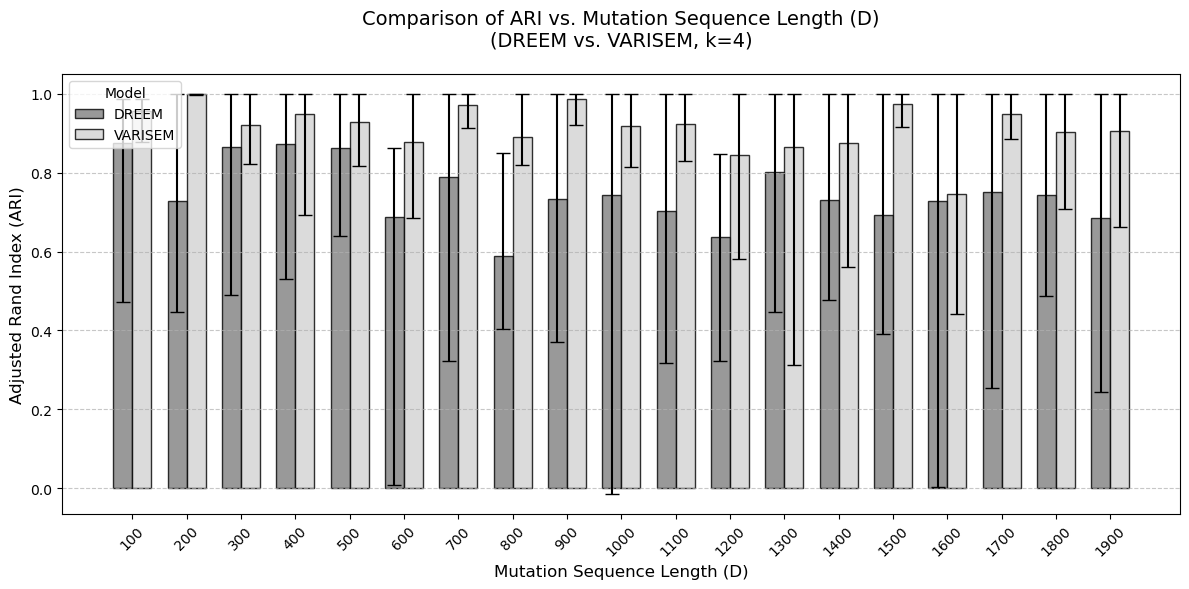

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Setup
bar_width = 0.35
x_positions = np.arange(len(df_summary["D"]))

plt.figure(figsize=(12, 6))

# Plot DREEM ARI
plt.bar(
    x_positions - bar_width / 2,
    df_summary["ARI_DREEM_mean"],
    yerr=[
        df_summary["ARI_DREEM_min_err"],
        df_summary["ARI_DREEM_max_err"]
    ],
    capsize=5,
    color="gray",
    edgecolor="black",
    width=bar_width,
    label="DREEM",
    alpha=0.8
)

# Plot VARISEM ARI
plt.bar(
    x_positions + bar_width / 2,
    df_summary["ARI_VARISEM_mean"],
    yerr=[
        df_summary["ARI_VARISEM_min_err"],
        df_summary["ARI_VARISEM_max_err"]
    ],
    capsize=5,
    color="lightgray",
    edgecolor="black",
    width=bar_width,
    label="VARISEM",
    alpha=0.8
)


# Labels and title
plt.xlabel("Mutation Sequence Length (D)", fontsize=12)
plt.ylabel("Adjusted Rand Index (ARI)", fontsize=12)
plt.title("Comparison of ARI vs. Mutation Sequence Length (D)\n(DREEM vs. VARISEM, k=4)", fontsize=14, pad=20)
plt.xticks(x_positions, df_summary["D"], rotation=45, fontsize=10)

plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.legend(title="Model", loc="upper left")

# Save and show the plot
plt.tight_layout()                  
filename = os.path.join(output_folder, "ARI_VARISEM_vs_DREEM_k=4.pdf")
plt.savefig(filename, format='pdf')
plt.show()

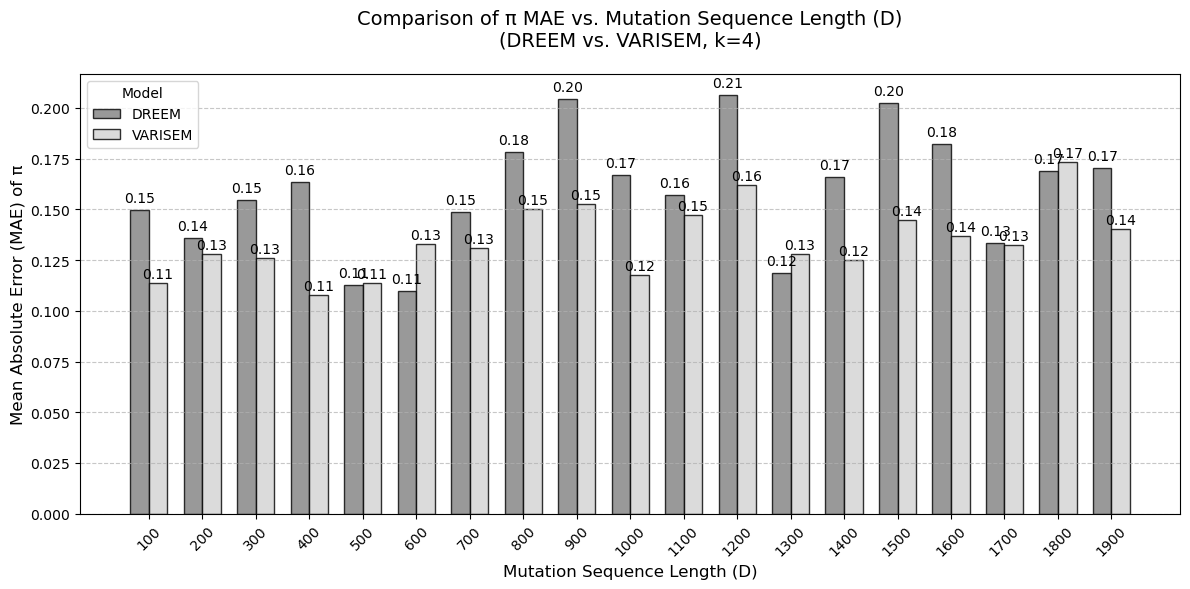

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting parameters
bar_width = 26
spacing =75

# Generate x-axis positions for each D value
x_labels = df_summary["D"]
x_positions = np.arange(len(x_labels)) * spacing

# Create the figure
plt.figure(figsize=(12, 6))

# Plot DREEM pi_MAE bars
bars_dreem = plt.bar(
    x_positions - bar_width / 2,
    df_summary["pi_MAE_DREEM_mean"],
    color="gray",
    edgecolor="black",
    width=bar_width,
    label="DREEM",
    alpha=0.8
)

# Plot VARISEM pi_MAE bars
bars_varisem = plt.bar(
    x_positions + bar_width / 2,
    df_summary["pi_MAE_VARISEM_mean"],
    color="lightgray",
    edgecolor="black",
    width=bar_width,
    label="VARISEM",
    alpha=0.8
)

# Add value labels on top of each bar
for bar, value in zip(bars_dreem, df_summary["pi_MAE_DREEM_mean"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0025,     # A small offset above the bar
        f"{value:.2f}",              # Format to 3 decimal places (adjust as needed)
        ha="center",
        va="bottom",
        fontsize=10
    )

for bar, value in zip(bars_varisem, df_summary["pi_MAE_VARISEM_mean"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Customize labels and title
plt.xlabel("Mutation Sequence Length (D)", fontsize=12)
plt.ylabel("Mean Absolute Error (MAE) of π", fontsize=12)
plt.title("Comparison of π MAE vs. Mutation Sequence Length (D)\n(DREEM vs. VARISEM, k=4)", fontsize=14, pad=20)

# Customize ticks
plt.xticks(x_positions, x_labels, rotation=45, fontsize=10)
plt.yticks(fontsize=10)

# Add grid and legend
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.legend(title="Model", loc="upper left")
# Save and show the plot
plt.tight_layout()
filename = os.path.join(output_folder, "pi_MAE_VARISEM_vs_DREEM_k=4.pdf")
plt.savefig(filename, format='pdf')    
plt.show()


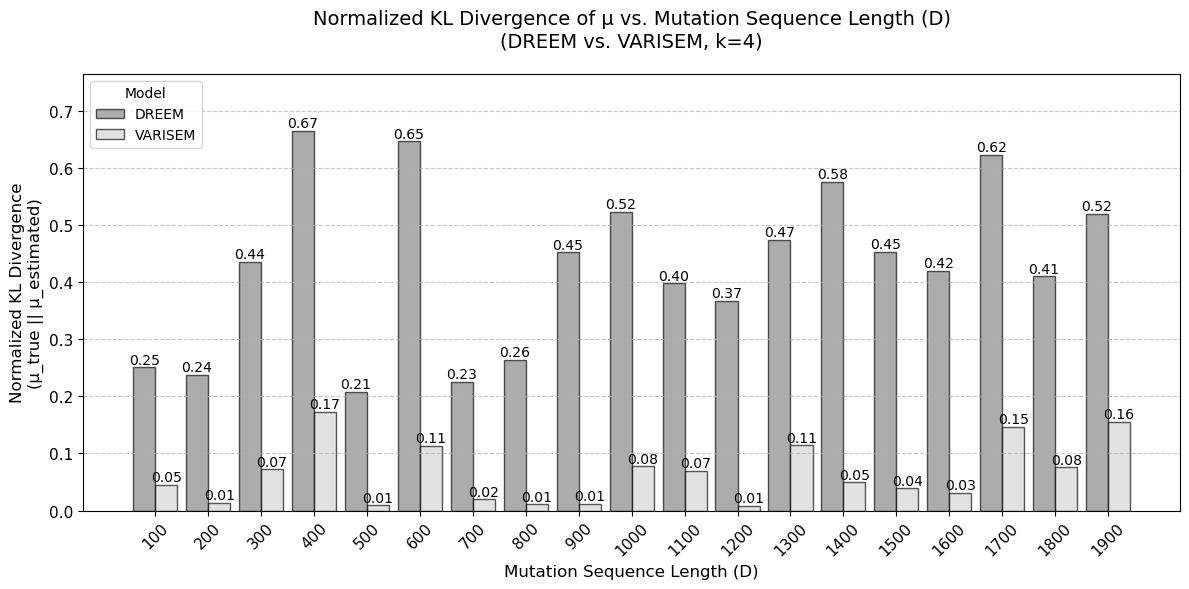

In [16]:
# Plotting parameters
bar_width = 25
spacing = 60  # space between groups

# Generate x-axis positions for each D value
x_labels = df_summary_norm["D"]  # <--- use df_summary_norm here
x_positions = np.arange(len(x_labels)) * spacing

plt.figure(figsize=(12, 6))

# Plot DREEM normalized KL divergence bars
bars_dreem = plt.bar(
    x_positions - bar_width / 2,
    df_summary_norm["DREEM_mean"],  # <--- use df_summary_norm
    color="gray",
    edgecolor="black",
    width=bar_width,
    label="DREEM",
    alpha=0.65
)

# Plot VARISEM normalized KL divergence bars
bars_varisem = plt.bar(
    x_positions + bar_width / 2,
    df_summary_norm["VARISEM_mean"],  # <--- use df_summary_norm
    color="lightgray",
    edgecolor="black",
    width=bar_width,
    label="VARISEM",
    alpha=0.65
)

# Add value labels for both bars
for bar, value in zip(bars_dreem, df_summary_norm["DREEM_mean"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

for bar, value in zip(bars_varisem, df_summary_norm["VARISEM_mean"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Customize labels and title
plt.xlabel("Mutation Sequence Length (D)", fontsize=12)
plt.ylabel("Normalized KL Divergence\n(μ_true || μ_estimated)", fontsize=12)
plt.title("Normalized KL Divergence of μ vs. Mutation Sequence Length (D)\n(DREEM vs. VARISEM, k=4)", fontsize=14, pad=20)

plt.xticks(x_positions, x_labels, rotation=45, fontsize=11)
plt.yticks(fontsize=11)

# Y-axis limit adjustment
y_max = max(df_summary_norm["DREEM_mean"].max(), df_summary_norm["VARISEM_mean"].max()) + 0.1
plt.ylim(0, min(1, y_max))  # Cap the upper limit at 1 if necessary

plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.legend(title="Model", loc="upper left")
plt.tight_layout()

filename = os.path.join(output_folder, "mu_KL_normalized_VARISEM_vs_DREEM_k=4.pdf")
plt.savefig(filename, format='pdf')   
plt.show()


# K=5

In [68]:
output_folder = "k=5"
os.makedirs(output_folder, exist_ok=True)
D_values = np.arange(100, 2000, 100)
#D_values = [50, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
N_values = [100, 200, 300, 500, 600, 800]

results = []

for D in D_values:
    for N in N_values:
        np.random.seed(314)
        K = 5
        alpha = np.ones(K) * 2

        pi_true = np.random.dirichlet(alpha)
        a, b = 2, 5
        mu_true = np.random.beta(a, b, (K, D))

        Z_true = np.random.choice(K, size=N, p=pi_true)
        X_D = np.zeros((N, D), dtype=int)

        for n in range(N):
            cluster = Z_true[n]
            X_D[n, :] = np.random.binomial(1, mu_true[cluster, :])

        vi_model_bmm_mean = VARISEM(X_D, K, max_iter=300, tol=1e-6)
        vi_model_bmm_mean.fit()

        Z_pred = np.argmax(vi_model_bmm_mean.q_nk, axis=1)
        ari_score = adjusted_rand_score(Z_true, Z_pred)

        pi_estimated = vi_model_bmm_mean.pi_k_mean
        pi_mae = np.mean(np.abs(pi_true - pi_estimated))

        # Compute KL divergence for mu
        kl_divergences = []
        for k in range(K):
            kl_k = kl_bernoulli(mu_true[k, :], vi_model_bmm_mean.mu_ki_mean[k, :])
            kl_divergences.append(kl_k)
        kl_divergence_mean = np.mean(kl_divergences)

        results.append([D, N, ari_score, pi_mae, kl_divergence_mean])

# Create DataFrame
df_results = pd.DataFrame(results, columns=["D", "N", "ARI", "pi_MAE", "mu_KL"])
filename_csv = os.path.join(output_folder, "VARISEM_ARI_pi_mu_k=5.csv")
df_results.to_csv(filename_csv, index=False)

Iteration 0, ELBO: 10641.5409
Iteration 10, ELBO: 10551.0344
Iteration 20, ELBO: 10540.9545
Iteration 30, ELBO: 10504.6398
Iteration 40, ELBO: 10503.8639
Converged at iteration 50.
Optimization complete.
Iteration 0, ELBO: 16253.1577
Iteration 10, ELBO: 16111.4953
Iteration 20, ELBO: 16069.4228
Iteration 30, ELBO: 16070.0682
Iteration 40, ELBO: 16044.9837
Iteration 50, ELBO: 16044.2419
Iteration 60, ELBO: 16044.2646
Iteration 70, ELBO: 16044.2730
Iteration 80, ELBO: 16044.2765
Iteration 90, ELBO: 16044.2781
Iteration 100, ELBO: 16044.2789
Iteration 110, ELBO: 16044.2793
Iteration 120, ELBO: 16044.2794
Iteration 130, ELBO: 16044.2795
Iteration 140, ELBO: 16044.2796
Iteration 150, ELBO: 16044.2796
Converged at iteration 155.
Optimization complete.
Iteration 0, ELBO: 21756.6752
Iteration 10, ELBO: 21659.4591
Iteration 20, ELBO: 21580.4233
Iteration 30, ELBO: 21580.4205
Converged at iteration 33.
Optimization complete.
Iteration 0, ELBO: 32505.7543
Iteration 10, ELBO: 32501.8796
Iteration 

In [69]:
results = []

for D in D_values:
    for N in N_values:
        np.random.seed(314)
        K = 5
        alpha = np.ones(K) * 2

        # Generate true parameters
        pi_true = np.random.dirichlet(alpha)
        a, b = 2, 5
        mu_true = np.random.beta(a, b, (K, D))

        Z_true = np.random.choice(K, size=N, p=pi_true)
        X_D = np.zeros((N, D), dtype=int)

        for n in range(N):
            cluster = Z_true[n]
            X_D[n, :] = np.random.binomial(1, mu_true[cluster, :])

        # Run DREEM
        dreem_model = DREEM(X_D, K, max_iter=300, tol=1e-6)
        dreem_model.fit()

        Z_pred_dreem = dreem_model.predict()
        ari_dreem = adjusted_rand_score(Z_true, Z_pred_dreem)

        # Calculate pi MAE
        pi_estimated = dreem_model.pi
        pi_mae = np.mean(np.abs(pi_true - pi_estimated))

        # Calculate mu KL divergence
        kl_divergences = []
        for k in range(K):
            kl_k = kl_bernoulli(mu_true[k, :], dreem_model.mu[k, :])
            kl_divergences.append(kl_k)
        mu_kl = np.mean(kl_divergences)

        results.append([D, N, ari_dreem, pi_mae, mu_kl])

df_results = pd.DataFrame(results, columns=["D", "N", "ARI_DREEM", "pi_MAE_DREEM", "mu_KL_DREEM"])
filename_csv = os.path.join(output_folder, "DREEM_ARI_pi_mu_k=5.csv")
df_results.to_csv(filename_csv, index=False)

Converged at iteration 28.
Optimization complete.
Converged at iteration 31.
Optimization complete.
Converged at iteration 32.
Optimization complete.
Converged at iteration 41.
Optimization complete.
Converged at iteration 75.
Optimization complete.
Converged at iteration 58.
Optimization complete.
Converged at iteration 8.
Optimization complete.
Converged at iteration 16.
Optimization complete.
Converged at iteration 15.
Optimization complete.
Converged at iteration 34.
Optimization complete.
Optimization complete.
Converged at iteration 7.
Optimization complete.
Converged at iteration 25.
Optimization complete.
Converged at iteration 22.
Optimization complete.
Converged at iteration 11.
Optimization complete.
Converged at iteration 26.
Optimization complete.
Converged at iteration 8.
Optimization complete.
Converged at iteration 9.
Optimization complete.
Converged at iteration 29.
Optimization complete.
Converged at iteration 10.
Optimization complete.
Converged at iteration 9.
Optim

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

filename_dreem_csv = os.path.join(output_folder, "DREEM_ARI_pi_mu_k=5.csv")
filename_varisem_csv = os.path.join(output_folder, "VARISEM_ARI_pi_mu_k=5.csv")

# Now read from those files
df_dreem = pd.read_csv(filename_dreem_csv)
df_varisem = pd.read_csv(filename_varisem_csv)

# Merge on D and N
df_combined = pd.merge(
    df_dreem,
    df_varisem,
    on=["D", "N"],
    suffixes=("_DREEM", "_VARISEM")
)

# Summary statistics
df_summary = df_combined.groupby("D").agg({
    "ARI_DREEM": ["mean", "min", "max"],
    "ARI": ["mean", "min", "max"],             # VARISEM ARI
    "pi_MAE_DREEM": ["mean", "min", "max"],
    "pi_MAE": ["mean", "min", "max"],          # VARISEM pi_MAE
    "mu_KL_DREEM": ["mean", "min", "max"],
    "mu_KL": ["mean", "min", "max"]            # VARISEM mu_KL
}).reset_index()

# Flatten MultiIndex columns
df_summary.columns = [
    "D",
    "ARI_DREEM_mean", "ARI_DREEM_min", "ARI_DREEM_max",
    "ARI_VARISEM_mean", "ARI_VARISEM_min", "ARI_VARISEM_max",
    "pi_MAE_DREEM_mean", "pi_MAE_DREEM_min", "pi_MAE_DREEM_max",
    "pi_MAE_VARISEM_mean", "pi_MAE_VARISEM_min", "pi_MAE_VARISEM_max",
    "mu_KL_DREEM_mean", "mu_KL_DREEM_min", "mu_KL_DREEM_max",
    "mu_KL_VARISEM_mean", "mu_KL_VARISEM_min", "mu_KL_VARISEM_max"
]

# -------------------------
# Compute Error Bars
# -------------------------

# ARI Error Bars
df_summary["ARI_DREEM_min_err"] = df_summary["ARI_DREEM_mean"] - df_summary["ARI_DREEM_min"]
df_summary["ARI_DREEM_max_err"] = df_summary["ARI_DREEM_max"] - df_summary["ARI_DREEM_mean"]
df_summary["ARI_VARISEM_min_err"] = df_summary["ARI_VARISEM_mean"] - df_summary["ARI_VARISEM_min"]
df_summary["ARI_VARISEM_max_err"] = df_summary["ARI_VARISEM_max"] - df_summary["ARI_VARISEM_mean"]

# pi_MAE Error Bars
df_summary["pi_MAE_DREEM_min_err"] = df_summary["pi_MAE_DREEM_mean"] - df_summary["pi_MAE_DREEM_min"]
df_summary["pi_MAE_DREEM_max_err"] = df_summary["pi_MAE_DREEM_max"] - df_summary["pi_MAE_DREEM_mean"]
df_summary["pi_MAE_VARISEM_min_err"] = df_summary["pi_MAE_VARISEM_mean"] - df_summary["pi_MAE_VARISEM_min"]
df_summary["pi_MAE_VARISEM_max_err"] = df_summary["pi_MAE_VARISEM_max"] - df_summary["pi_MAE_VARISEM_mean"]

# mu_KL Error Bars
df_summary["mu_KL_DREEM_min_err"] = df_summary["mu_KL_DREEM_mean"] - df_summary["mu_KL_DREEM_min"]
df_summary["mu_KL_DREEM_max_err"] = df_summary["mu_KL_DREEM_max"] - df_summary["mu_KL_DREEM_mean"]
df_summary["mu_KL_VARISEM_min_err"] = df_summary["mu_KL_VARISEM_mean"] - df_summary["mu_KL_VARISEM_min"]
df_summary["mu_KL_VARISEM_max_err"] = df_summary["mu_KL_VARISEM_max"] - df_summary["mu_KL_VARISEM_mean"]

# -------------------------
# Normalize mu_KL values per D group
# -------------------------

# Compute min/max across both methods for mu_KL at the summary level
df_summary["KL_min"] = df_summary[["mu_KL_DREEM_mean", "mu_KL_VARISEM_mean"]].min(axis=1)
df_summary["KL_max"] = df_summary[["mu_KL_DREEM_mean", "mu_KL_VARISEM_mean"]].max(axis=1)

# Normalize mean mu_KL values
df_summary["mu_KL_DREEM_norm"] = (df_summary["mu_KL_DREEM_mean"] - df_summary["KL_min"]) / (df_summary["KL_max"] - df_summary["KL_min"])
df_summary["mu_KL_VARISEM_norm"] = (df_summary["mu_KL_VARISEM_mean"] - df_summary["KL_min"]) / (df_summary["KL_max"] - df_summary["KL_min"])

# -------------------------
# Normalize mu_KL at row level for df_combined
# -------------------------

# Compute min/max per D across both methods
kl_min_max = df_combined.groupby("D")[["mu_KL_DREEM", "mu_KL"]].agg(["min", "max"]).reset_index()

# Flatten columns
kl_min_max.columns = [
    "D",
    "mu_KL_DREEM_min", "mu_KL_DREEM_max",
    "mu_KL_VARISEM_min", "mu_KL_VARISEM_max"
]

# Compute KL_min and KL_max for normalization
kl_min_max["KL_min"] = kl_min_max[["mu_KL_DREEM_min", "mu_KL_VARISEM_min"]].min(axis=1)
kl_min_max["KL_max"] = kl_min_max[["mu_KL_DREEM_max", "mu_KL_VARISEM_max"]].max(axis=1)

# Merge KL_min and KL_max back into df_combined for normalization
df_combined = df_combined.merge(kl_min_max[["D", "KL_min", "KL_max"]], on="D", how="left")

# Normalize row-level mu_KL values
df_combined["mu_KL_DREEM_norm"] = (df_combined["mu_KL_DREEM"] - df_combined["KL_min"]) / (df_combined["KL_max"] - df_combined["KL_min"])
df_combined["mu_KL_VARISEM_norm"] = (df_combined["mu_KL"] - df_combined["KL_min"]) / (df_combined["KL_max"] - df_combined["KL_min"])

# Aggregate normalized scores at D level
df_summary_norm = df_combined.groupby("D").agg({
    "mu_KL_DREEM_norm": "mean",
    "mu_KL_VARISEM_norm": "mean"
}).reset_index()

# Rename columns for clarity
df_summary_norm.columns = ["D", "DREEM_mean", "VARISEM_mean"]

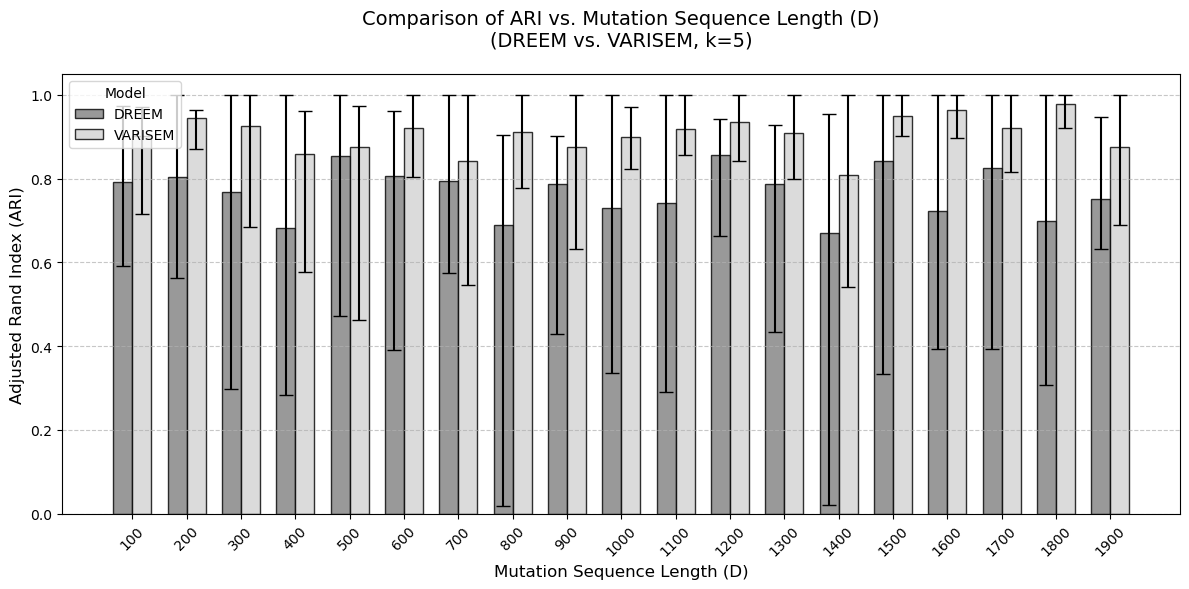

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Setup
bar_width = 0.35
x_positions = np.arange(len(df_summary["D"]))

plt.figure(figsize=(12, 6))

# Plot DREEM ARI
plt.bar(
    x_positions - bar_width / 2,
    df_summary["ARI_DREEM_mean"],
    yerr=[
        df_summary["ARI_DREEM_min_err"],
        df_summary["ARI_DREEM_max_err"]
    ],
    capsize=5,
    color="gray",
    edgecolor="black",
    width=bar_width,
    label="DREEM",
    alpha=0.8
)

# Plot VARISEM ARI
plt.bar(
    x_positions + bar_width / 2,
    df_summary["ARI_VARISEM_mean"],
    yerr=[
        df_summary["ARI_VARISEM_min_err"],
        df_summary["ARI_VARISEM_max_err"]
    ],
    capsize=5,
    color="lightgray",
    edgecolor="black",
    width=bar_width,
    label="VARISEM",
    alpha=0.8
)


# Labels and title
plt.xlabel("Mutation Sequence Length (D)", fontsize=12)
plt.ylabel("Adjusted Rand Index (ARI)", fontsize=12)
plt.title("Comparison of ARI vs. Mutation Sequence Length (D)\n(DREEM vs. VARISEM, k=5)", fontsize=14, pad=20)
plt.xticks(x_positions, df_summary["D"], rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.legend(title="Model", loc="upper left")

# Save and show the plot
plt.tight_layout()
filename = os.path.join(output_folder, "ARI_VARISEM_vs_DREEM_k=5.pdf")
plt.savefig(filename, format='pdf')   
plt.show()

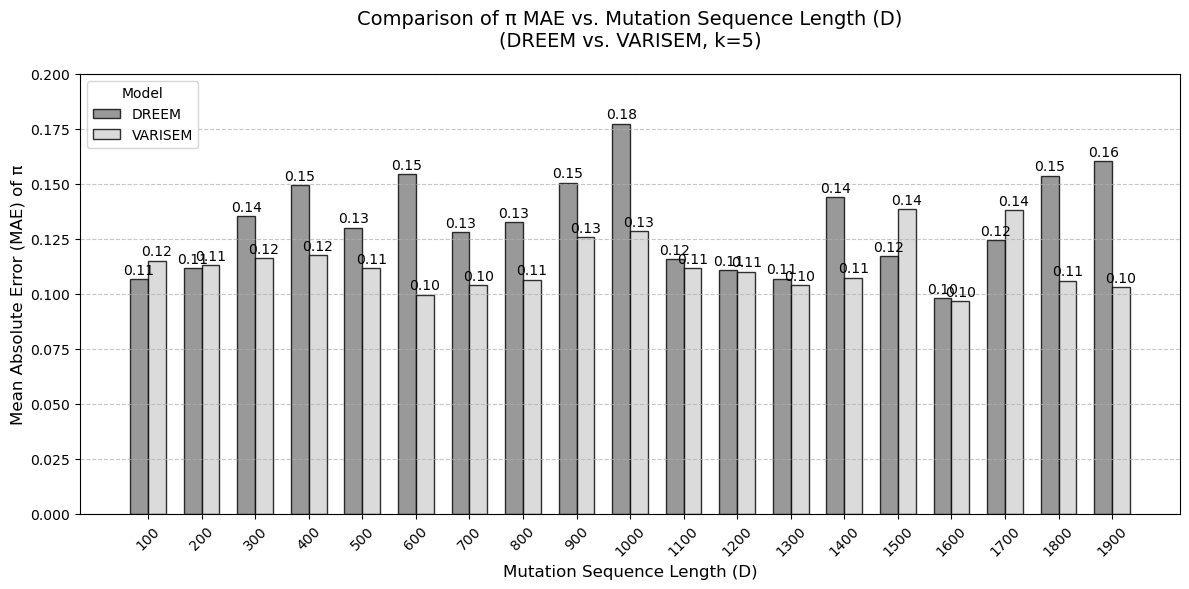

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting parameters
bar_width = 20
spacing = 60

# Generate x-axis positions for each D value
x_labels = df_summary["D"]
x_positions = np.arange(len(x_labels)) * spacing

# Create the figure
plt.figure(figsize=(12, 6))

# Plot DREEM pi_MAE bars
bars_dreem = plt.bar(
    x_positions - bar_width / 2,
    df_summary["pi_MAE_DREEM_mean"],
    color="gray",
    edgecolor="black",
    width=bar_width,
    label="DREEM",
    alpha=0.8
)

# Plot VARISEM pi_MAE bars
bars_varisem = plt.bar(
    x_positions + bar_width / 2,
    df_summary["pi_MAE_VARISEM_mean"],
    color="lightgray",
    edgecolor="black",
    width=bar_width,
    label="VARISEM",
    alpha=0.8
)

# Add value labels on top of each bar
for bar, value in zip(bars_dreem, df_summary["pi_MAE_DREEM_mean"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,     # A small offset above the bar
        f"{value:.2f}",              # Format to 3 decimal places (adjust as needed)
        ha="center",
        va="bottom",
        fontsize=10
    )

for bar, value in zip(bars_varisem, df_summary["pi_MAE_VARISEM_mean"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Customize labels and title
plt.xlabel("Mutation Sequence Length (D)", fontsize=12)
plt.ylabel("Mean Absolute Error (MAE) of π", fontsize=12)
plt.title("Comparison of π MAE vs. Mutation Sequence Length (D)\n(DREEM vs. VARISEM, k=5)", fontsize=14, pad=20)
plt.ylim(0, 0.2)

# Customize ticks
plt.xticks(x_positions, x_labels, rotation=45, fontsize=10)
plt.yticks(fontsize=10)

# Add grid and legend
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.legend(title="Model", loc="upper left")
# Save and show the plot
plt.tight_layout()
filename = os.path.join(output_folder, "pi_MAE_VARISEM_vs_DREEM_k=5.pdf")
plt.savefig(filename, format='pdf')   
plt.show()


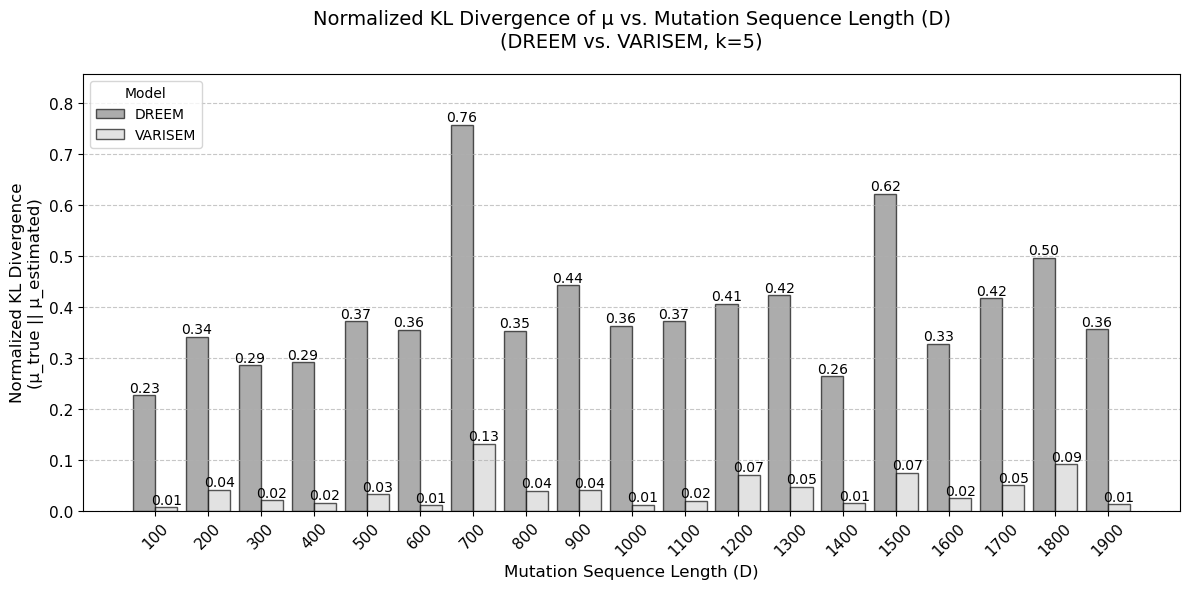

In [26]:
# Plotting parameters
bar_width = 25
spacing = 60  # space between groups

# Generate x-axis positions for each D value
x_labels = df_summary_norm["D"]  # <--- use df_summary_norm here
x_positions = np.arange(len(x_labels)) * spacing

plt.figure(figsize=(12, 6))

# Plot DREEM normalized KL divergence bars
bars_dreem = plt.bar(
    x_positions - bar_width / 2,
    df_summary_norm["DREEM_mean"],  # <--- use df_summary_norm
    color="gray",
    edgecolor="black",
    width=bar_width,
    label="DREEM",
    alpha=0.65
)

# Plot VARISEM normalized KL divergence bars
bars_varisem = plt.bar(
    x_positions + bar_width / 2,
    df_summary_norm["VARISEM_mean"],  # <--- use df_summary_norm
    color="lightgray",
    edgecolor="black",
    width=bar_width,
    label="VARISEM",
    alpha=0.65
)

# Add value labels for both bars
for bar, value in zip(bars_dreem, df_summary_norm["DREEM_mean"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

for bar, value in zip(bars_varisem, df_summary_norm["VARISEM_mean"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Customize labels and title
plt.xlabel("Mutation Sequence Length (D)", fontsize=12)
plt.ylabel("Normalized KL Divergence\n(μ_true || μ_estimated)", fontsize=12)
plt.title("Normalized KL Divergence of μ vs. Mutation Sequence Length (D)\n(DREEM vs. VARISEM, k=5)", fontsize=14, pad=20)

plt.xticks(x_positions, x_labels, rotation=45, fontsize=11)
plt.yticks(fontsize=11)

# Y-axis limit adjustment
y_max = max(df_summary_norm["DREEM_mean"].max(), df_summary_norm["VARISEM_mean"].max()) + 0.1
plt.ylim(0, min(1, y_max))  # Cap the upper limit at 1 if necessary

plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.legend(title="Model", loc="upper left")
plt.tight_layout()
filename = os.path.join(output_folder, "mu_KL_normalized_VARISEM_vs_DREEM_k=5.pdf")
plt.savefig(filename, format='pdf')   
plt.show()


# K=2

In [100]:
output_folder = "k=2"
os.makedirs(output_folder, exist_ok=True)
D_values = np.arange(100, 2000, 100)
#D_values = [50, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
N_values = [100, 200, 300, 500, 600, 800]

results = []

for D in D_values:
    for N in N_values:
        np.random.seed(143)
        K = 2
        alpha = np.ones(K) * 2

        pi_true = np.random.dirichlet(alpha)
        a, b = 2, 5
        mu_true = np.random.beta(a, b, (K, D))

        Z_true = np.random.choice(K, size=N, p=pi_true)
        X_D = np.zeros((N, D), dtype=int)

        for n in range(N):
            cluster = Z_true[n]
            X_D[n, :] = np.random.binomial(1, mu_true[cluster, :])

        vi_model_bmm_mean = VARISEM(X_D, K, max_iter=300, tol=1e-6)
        vi_model_bmm_mean.fit()

        Z_pred = np.argmax(vi_model_bmm_mean.q_nk, axis=1)
        ari_score = adjusted_rand_score(Z_true, Z_pred)

        pi_estimated = vi_model_bmm_mean.pi_k_mean
        pi_mae = np.mean(np.abs(pi_true - pi_estimated))

        # Compute KL divergence for mu
        kl_divergences = []
        for k in range(K):
            kl_k = kl_bernoulli(mu_true[k, :], vi_model_bmm_mean.mu_ki_mean[k, :])
            kl_divergences.append(kl_k)
        kl_divergence_mean = np.mean(kl_divergences)

        results.append([D, N, ari_score, pi_mae, kl_divergence_mean])

# Create DataFrame
df_results = pd.DataFrame(results, columns=["D", "N", "ARI", "pi_MAE", "mu_KL"])
filename_csv = os.path.join(output_folder, "VARISEM_ARI_pi_mu_k=2.csv")
df_results.to_csv(filename_csv, index=False)

Iteration 0, ELBO: 7602.8536
Iteration 10, ELBO: 7518.7034
Converged at iteration 16.
Optimization complete.
Iteration 0, ELBO: 13131.1152
Converged at iteration 7.
Optimization complete.
Iteration 0, ELBO: 18785.7634
Iteration 10, ELBO: 18786.1421
Converged at iteration 17.
Optimization complete.
Iteration 0, ELBO: 29829.0629
Converged at iteration 6.
Optimization complete.
Iteration 0, ELBO: 35279.1671
Iteration 10, ELBO: 35276.6717
Converged at iteration 12.
Optimization complete.
Iteration 0, ELBO: 46433.8317
Iteration 10, ELBO: 46430.9680
Converged at iteration 13.
Optimization complete.
Iteration 0, ELBO: 14824.9193
Converged at iteration 1.
Optimization complete.
Iteration 0, ELBO: 26241.6354
Converged at iteration 7.
Optimization complete.
Iteration 0, ELBO: 36106.8828
Converged at iteration 2.
Optimization complete.
Iteration 0, ELBO: 57386.8851
Converged at iteration 1.
Optimization complete.
Iteration 0, ELBO: 67757.3891
Converged at iteration 1.
Optimization complete.
Itera

In [88]:
results = []

for D in D_values:
    for N in N_values:
        np.random.seed(819)
        K = 25
        alpha = np.ones(K) * 2

        # Generate true parameters
        pi_true = np.random.dirichlet(alpha)
        a, b = 2, 5
        mu_true = np.random.beta(a, b, (K, D))

        Z_true = np.random.choice(K, size=N, p=pi_true)
        X_D = np.zeros((N, D), dtype=int)

        for n in range(N):
            cluster = Z_true[n]
            X_D[n, :] = np.random.binomial(1, mu_true[cluster, :])

        # Run DREEM
        dreem_model = DREEM(X_D, K, max_iter=300, tol=1e-6)
        dreem_model.fit()

        Z_pred_dreem = dreem_model.predict()
        ari_dreem = adjusted_rand_score(Z_true, Z_pred_dreem)

        # Calculate pi MAE
        pi_estimated = dreem_model.pi
        pi_mae = np.mean(np.abs(pi_true - pi_estimated))

        # Calculate mu KL divergence
        kl_divergences = []
        for k in range(K):
            kl_k = kl_bernoulli(mu_true[k, :], dreem_model.mu[k, :])
            kl_divergences.append(kl_k)
        mu_kl = np.mean(kl_divergences)

        results.append([D, N, ari_dreem, pi_mae, mu_kl])

df_results = pd.DataFrame(results, columns=["D", "N", "ARI_DREEM", "pi_MAE_DREEM", "mu_KL_DREEM"])
filename_csv = os.path.join(output_folder, "DREEM_ARI_pi_mu_k=2.csv")
df_results.to_csv(filename_csv, index=False)

Converged at iteration 13.
Optimization complete.
Converged at iteration 30.
Optimization complete.
Converged at iteration 91.
Optimization complete.
Optimization complete.
Converged at iteration 113.
Optimization complete.
Converged at iteration 139.
Optimization complete.
Converged at iteration 8.
Optimization complete.
Converged at iteration 33.
Optimization complete.
Converged at iteration 50.
Optimization complete.
Converged at iteration 44.
Optimization complete.
Converged at iteration 45.
Optimization complete.
Converged at iteration 62.
Optimization complete.
Converged at iteration 3.
Optimization complete.
Converged at iteration 33.
Optimization complete.
Converged at iteration 43.
Optimization complete.
Converged at iteration 23.
Optimization complete.
Converged at iteration 28.
Optimization complete.
Converged at iteration 46.
Optimization complete.
Converged at iteration 3.
Optimization complete.
Converged at iteration 14.
Optimization complete.
Converged at iteration 39.
O

In [61]:
print(output_folder)

k=2


In [62]:
!pwd

/Users/liangjialu/Documents


In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

filename_dreem_csv = os.path.join(output_folder, "DREEM_ARI_pi_mu_k=2.csv")
filename_varisem_csv = os.path.join(output_folder, "VARISEM_ARI_pi_mu_k=2.csv")

# Now read from those files
df_dreem = pd.read_csv(filename_dreem_csv)
df_varisem = pd.read_csv(filename_varisem_csv)

# Merge on D and N
df_combined = pd.merge(
    df_dreem,
    df_varisem,
    on=["D", "N"],
    suffixes=("_DREEM", "_VARISEM")
)

# Summary statistics
df_summary = df_combined.groupby("D").agg({
    "ARI_DREEM": ["mean", "min", "max"],
    "ARI": ["mean", "min", "max"],             # VARISEM ARI
    "pi_MAE_DREEM": ["mean", "min", "max"],
    "pi_MAE": ["mean", "min", "max"],          # VARISEM pi_MAE
    "mu_KL_DREEM": ["mean", "min", "max"],
    "mu_KL": ["mean", "min", "max"]            # VARISEM mu_KL
}).reset_index()

# Flatten MultiIndex columns
df_summary.columns = [
    "D",
    "ARI_DREEM_mean", "ARI_DREEM_min", "ARI_DREEM_max",
    "ARI_VARISEM_mean", "ARI_VARISEM_min", "ARI_VARISEM_max",
    "pi_MAE_DREEM_mean", "pi_MAE_DREEM_min", "pi_MAE_DREEM_max",
    "pi_MAE_VARISEM_mean", "pi_MAE_VARISEM_min", "pi_MAE_VARISEM_max",
    "mu_KL_DREEM_mean", "mu_KL_DREEM_min", "mu_KL_DREEM_max",
    "mu_KL_VARISEM_mean", "mu_KL_VARISEM_min", "mu_KL_VARISEM_max"
]

# -------------------------
# Compute Error Bars
# -------------------------

# ARI Error Bars
df_summary["ARI_DREEM_min_err"] = df_summary["ARI_DREEM_mean"] - df_summary["ARI_DREEM_min"]
df_summary["ARI_DREEM_max_err"] = df_summary["ARI_DREEM_max"] - df_summary["ARI_DREEM_mean"]
df_summary["ARI_VARISEM_min_err"] = df_summary["ARI_VARISEM_mean"] - df_summary["ARI_VARISEM_min"]
df_summary["ARI_VARISEM_max_err"] = df_summary["ARI_VARISEM_max"] - df_summary["ARI_VARISEM_mean"]

# pi_MAE Error Bars
df_summary["pi_MAE_DREEM_min_err"] = df_summary["pi_MAE_DREEM_mean"] - df_summary["pi_MAE_DREEM_min"]
df_summary["pi_MAE_DREEM_max_err"] = df_summary["pi_MAE_DREEM_max"] - df_summary["pi_MAE_DREEM_mean"]
df_summary["pi_MAE_VARISEM_min_err"] = df_summary["pi_MAE_VARISEM_mean"] - df_summary["pi_MAE_VARISEM_min"]
df_summary["pi_MAE_VARISEM_max_err"] = df_summary["pi_MAE_VARISEM_max"] - df_summary["pi_MAE_VARISEM_mean"]

# mu_KL Error Bars
df_summary["mu_KL_DREEM_min_err"] = df_summary["mu_KL_DREEM_mean"] - df_summary["mu_KL_DREEM_min"]
df_summary["mu_KL_DREEM_max_err"] = df_summary["mu_KL_DREEM_max"] - df_summary["mu_KL_DREEM_mean"]
df_summary["mu_KL_VARISEM_min_err"] = df_summary["mu_KL_VARISEM_mean"] - df_summary["mu_KL_VARISEM_min"]
df_summary["mu_KL_VARISEM_max_err"] = df_summary["mu_KL_VARISEM_max"] - df_summary["mu_KL_VARISEM_mean"]

# -------------------------
# Normalize mu_KL values per D group
# -------------------------

# Compute min/max across both methods for mu_KL at the summary level
df_summary["KL_min"] = df_summary[["mu_KL_DREEM_mean", "mu_KL_VARISEM_mean"]].min(axis=1)
df_summary["KL_max"] = df_summary[["mu_KL_DREEM_mean", "mu_KL_VARISEM_mean"]].max(axis=1)

# Normalize mean mu_KL values
df_summary["mu_KL_DREEM_norm"] = (df_summary["mu_KL_DREEM_mean"] - df_summary["KL_min"]) / (df_summary["KL_max"] - df_summary["KL_min"])
df_summary["mu_KL_VARISEM_norm"] = (df_summary["mu_KL_VARISEM_mean"] - df_summary["KL_min"]) / (df_summary["KL_max"] - df_summary["KL_min"])

# -------------------------
# Normalize mu_KL at row level for df_combined
# -------------------------

# Compute min/max per D across both methods
kl_min_max = df_combined.groupby("D")[["mu_KL_DREEM", "mu_KL"]].agg(["min", "max"]).reset_index()

# Flatten columns
kl_min_max.columns = [
    "D",
    "mu_KL_DREEM_min", "mu_KL_DREEM_max",
    "mu_KL_VARISEM_min", "mu_KL_VARISEM_max"
]

# Compute KL_min and KL_max for normalization
kl_min_max["KL_min"] = kl_min_max[["mu_KL_DREEM_min", "mu_KL_VARISEM_min"]].min(axis=1)
kl_min_max["KL_max"] = kl_min_max[["mu_KL_DREEM_max", "mu_KL_VARISEM_max"]].max(axis=1)

# Merge KL_min and KL_max back into df_combined for normalization
df_combined = df_combined.merge(kl_min_max[["D", "KL_min", "KL_max"]], on="D", how="left")

# Normalize row-level mu_KL values
df_combined["mu_KL_DREEM_norm"] = (df_combined["mu_KL_DREEM"] - df_combined["KL_min"]) / (df_combined["KL_max"] - df_combined["KL_min"])
df_combined["mu_KL_VARISEM_norm"] = (df_combined["mu_KL"] - df_combined["KL_min"]) / (df_combined["KL_max"] - df_combined["KL_min"])

# Aggregate normalized scores at D level
df_summary_norm = df_combined.groupby("D").agg({
    "mu_KL_DREEM_norm": "mean",
    "mu_KL_VARISEM_norm": "mean"
}).reset_index()

# Rename columns for clarity
df_summary_norm.columns = ["D", "DREEM_mean", "VARISEM_mean"]

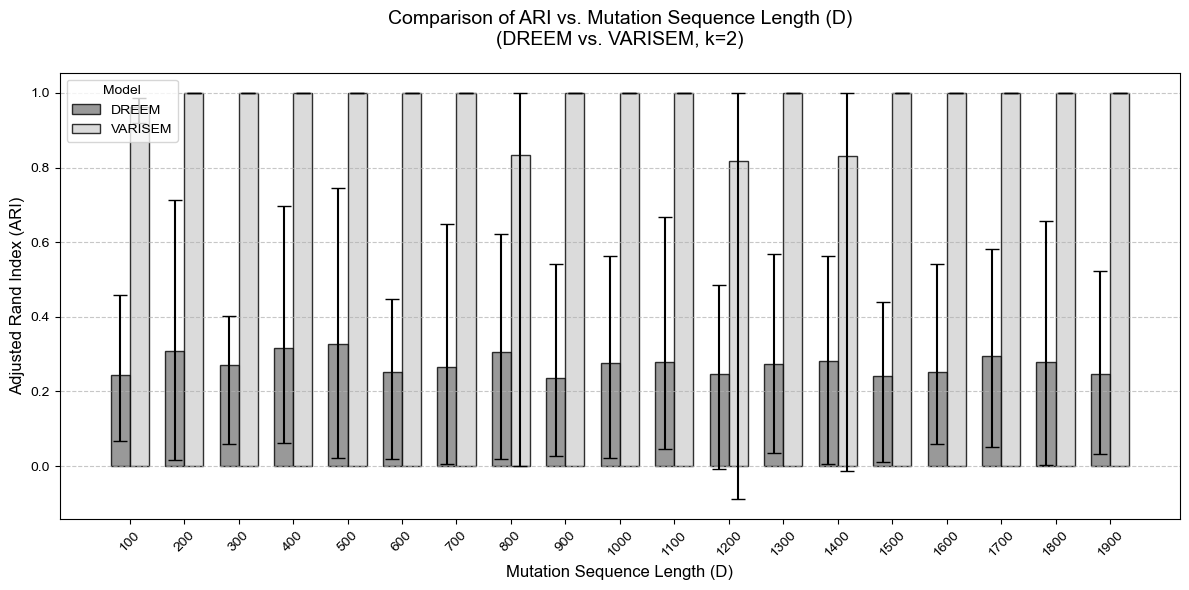

In [98]:
import matplotlib.pyplot as plt
import numpy as np

# Setup
bar_width = 0.35
x_positions = np.arange(len(df_summary["D"]))

plt.figure(figsize=(12, 6))

# Plot DREEM ARI
plt.bar(
    x_positions - bar_width / 2,
    df_summary["ARI_DREEM_mean"],
    yerr=[
        df_summary["ARI_DREEM_min_err"],
        df_summary["ARI_DREEM_max_err"]
    ],
    capsize=5,
    color="gray",
    edgecolor="black",
    width=bar_width,
    label="DREEM",
    alpha=0.8
)

# Plot VARISEM ARI
plt.bar(
    x_positions + bar_width / 2,
    df_summary["ARI_VARISEM_mean"],
    yerr=[
        df_summary["ARI_VARISEM_min_err"],
        df_summary["ARI_VARISEM_max_err"]
    ],
    capsize=5,
    color="lightgray",
    edgecolor="black",
    width=bar_width,
    label="VARISEM",
    alpha=0.8
)


# Labels and title
plt.xlabel("Mutation Sequence Length (D)", fontsize=12)
plt.ylabel("Adjusted Rand Index (ARI)", fontsize=12)
plt.title("Comparison of ARI vs. Mutation Sequence Length (D)\n(DREEM vs. VARISEM, k=2)", fontsize=14, pad=20)
plt.xticks(x_positions, df_summary["D"], rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.legend(title="Model", loc="upper left")

# Save and show the plot
plt.tight_layout()
filename = os.path.join(output_folder, "ARI_VARISEM_vs_DREEM_k=2.pdf")
plt.savefig(filename, format='pdf')   
plt.show()

/var/folders/2t/8rxz6gw54jvgsb_qdb0kks4rb933qw/T/ipykernel_85775/2415835944.py:72: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


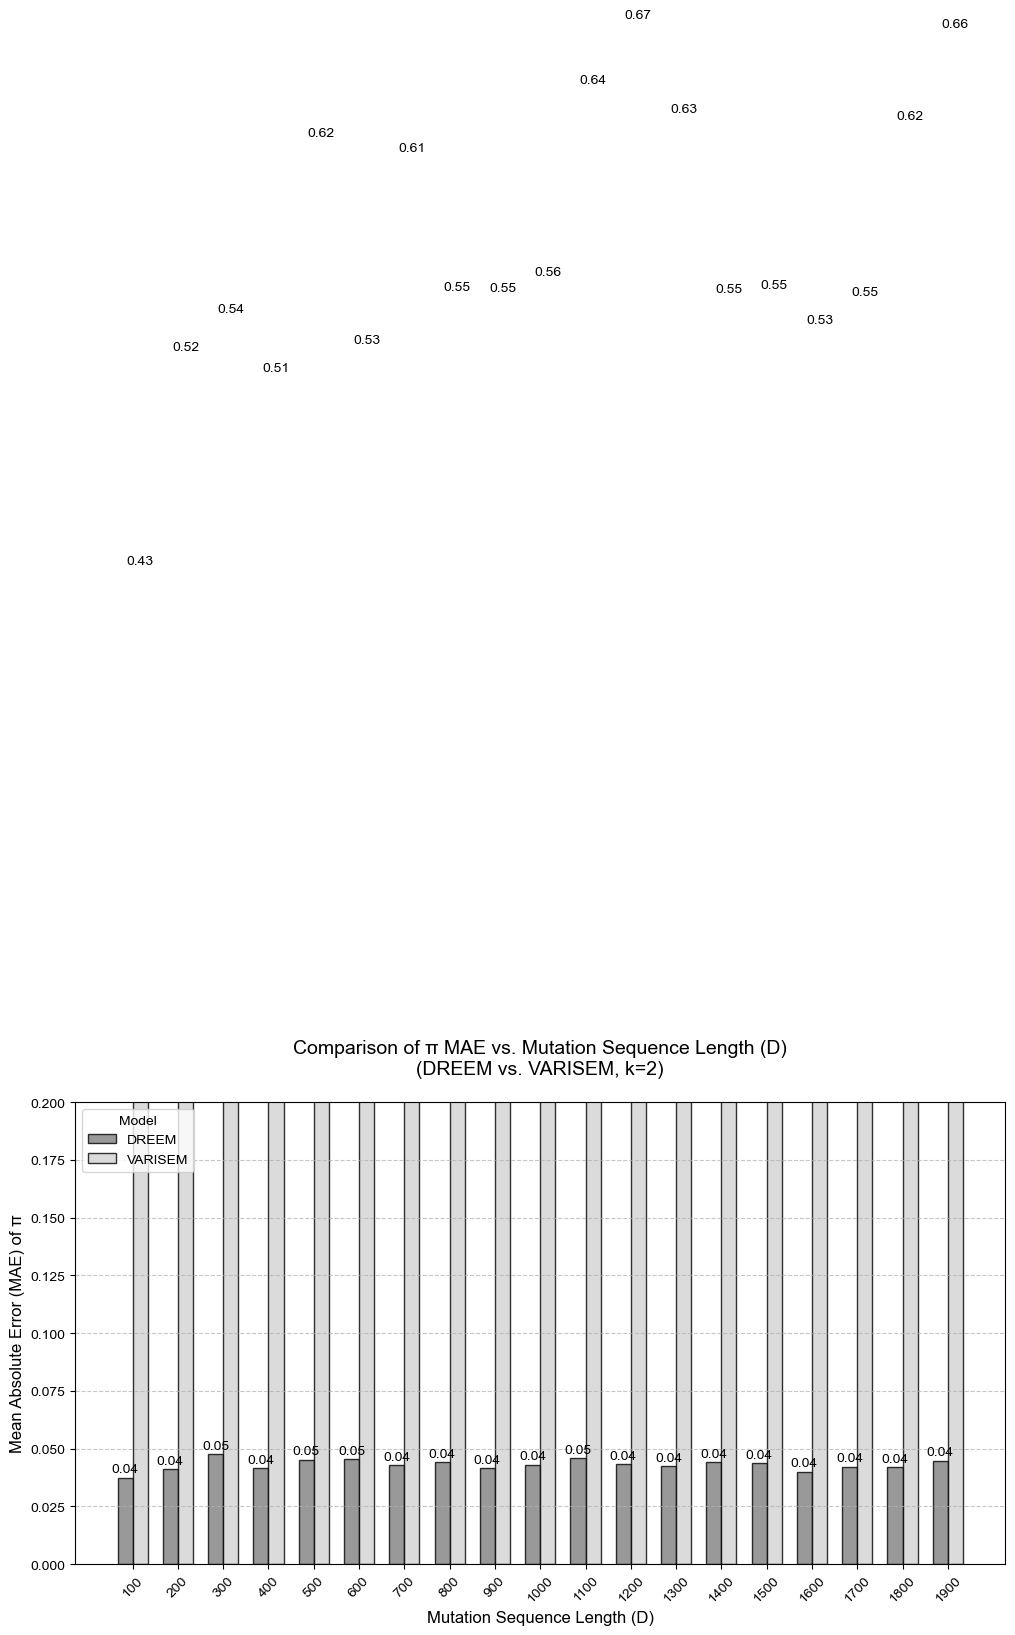

In [102]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting parameters
bar_width = 20
spacing = 60

# Generate x-axis positions for each D value
x_labels = df_summary["D"]
x_positions = np.arange(len(x_labels)) * spacing

# Create the figure
plt.figure(figsize=(12, 6))

# Plot DREEM pi_MAE bars
bars_dreem = plt.bar(
    x_positions - bar_width / 2,
    df_summary["pi_MAE_DREEM_mean"],
    color="gray",
    edgecolor="black",
    width=bar_width,
    label="DREEM",
    alpha=0.8
)

# Plot VARISEM pi_MAE bars
bars_varisem = plt.bar(
    x_positions + bar_width / 2,
    df_summary["pi_MAE_VARISEM_mean"],
    color="lightgray",
    edgecolor="black",
    width=bar_width,
    label="VARISEM",
    alpha=0.8
)

# Add value labels on top of each bar
for bar, value in zip(bars_dreem, df_summary["pi_MAE_DREEM_mean"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,     # A small offset above the bar
        f"{value:.2f}",              # Format to 3 decimal places (adjust as needed)
        ha="center",
        va="bottom",
        fontsize=10
    )

for bar, value in zip(bars_varisem, df_summary["pi_MAE_VARISEM_mean"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Customize labels and title
plt.xlabel("Mutation Sequence Length (D)", fontsize=12)
plt.ylabel("Mean Absolute Error (MAE) of π", fontsize=12)
plt.title("Comparison of π MAE vs. Mutation Sequence Length (D)\n(DREEM vs. VARISEM, k=2)", fontsize=14, pad=20)
plt.ylim(0, 0.2)

# Customize ticks
plt.xticks(x_positions, x_labels, rotation=45, fontsize=10)
plt.yticks(fontsize=10)

# Add grid and legend
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.legend(title="Model", loc="upper left")
# Save and show the plot
plt.tight_layout()
filename = os.path.join(output_folder, "pi_MAE_VARISEM_vs_DREEM_k=2.pdf")
plt.savefig(filename, format='pdf')   
plt.show()

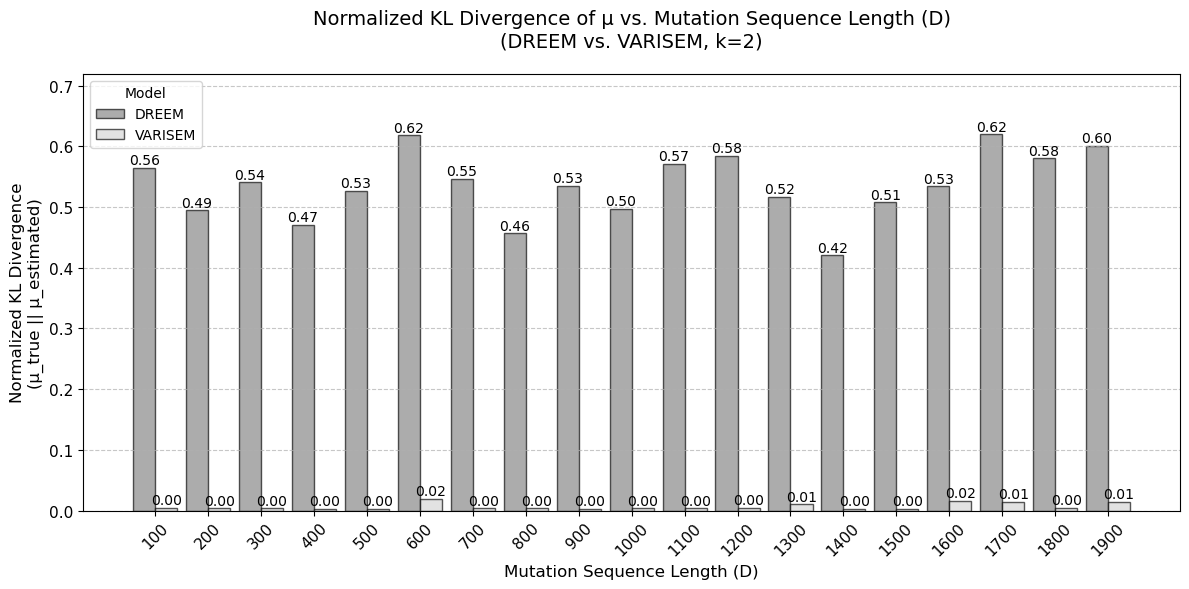

In [33]:
# Plotting parameters
bar_width = 25
spacing = 60  # space between groups

# Generate x-axis positions for each D value
x_labels = df_summary_norm["D"]  # <--- use df_summary_norm here
x_positions = np.arange(len(x_labels)) * spacing

plt.figure(figsize=(12, 6))

# Plot DREEM normalized KL divergence bars
bars_dreem = plt.bar(
    x_positions - bar_width / 2,
    df_summary_norm["DREEM_mean"],  # <--- use df_summary_norm
    color="gray",
    edgecolor="black",
    width=bar_width,
    label="DREEM",
    alpha=0.65
)

# Plot VARISEM normalized KL divergence bars
bars_varisem = plt.bar(
    x_positions + bar_width / 2,
    df_summary_norm["VARISEM_mean"],  # <--- use df_summary_norm
    color="lightgray",
    edgecolor="black",
    width=bar_width,
    label="VARISEM",
    alpha=0.65
)

# Add value labels for both bars
for bar, value in zip(bars_dreem, df_summary_norm["DREEM_mean"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

for bar, value in zip(bars_varisem, df_summary_norm["VARISEM_mean"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Customize labels and title
plt.xlabel("Mutation Sequence Length (D)", fontsize=12)
plt.ylabel("Normalized KL Divergence\n(μ_true || μ_estimated)", fontsize=12)
plt.title("Normalized KL Divergence of μ vs. Mutation Sequence Length (D)\n(DREEM vs. VARISEM, k=2)", fontsize=14, pad=20)

plt.xticks(x_positions, x_labels, rotation=45, fontsize=11)
plt.yticks(fontsize=11)

# Y-axis limit adjustment
y_max = max(df_summary_norm["DREEM_mean"].max(), df_summary_norm["VARISEM_mean"].max()) + 0.1
plt.ylim(0, min(1, y_max))  # Cap the upper limit at 1 if necessary

plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.legend(title="Model", loc="upper left")
plt.tight_layout()
filename = os.path.join(output_folder, "mu_KL_normalized_VARISEM_vs_DREEM_k=2.pdf")
plt.savefig(filename, format='pdf')   
plt.show()

# 